# Case Study 02: Stock Price Forecasting
This notebook contains the code for the case study on forecasting stock prices. We will go through a complete Bayesian workflow and apply the Vangja package to build and evaluate forecasting models for different stocks.

Our goal is to utilize historical stock market data from the S&P 500 index to improve the accuracy of its constituent stock price forecasts when the training data for the stocks is limited. The datasets used in this case study are daily data obtained from Yahoo Finance.

# 1. Dataset

## 1.1 Data loading and preprocessing

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

from vangja.datasets import load_stock_data, get_sp500_tickers_for_range
from vangja import FlatTrend, LinearTrend, FourierSeasonality, UniformConstant
from vangja.time_series import TimeSeriesModel
from vangja.utils import (
    metrics,
    plot_prior_predictive,
    prior_predictive_coverage,
    plot_posterior_predictive,
)

CT_PATH = Path("../data/sp500_constituents")
TICKERS_PATH = Path("../data/tickers")


def plot_dfs(dfs: list[pd.DataFrame], titles: list[str]):
    fig, axes = plt.subplots(len(dfs), 1, figsize=(14, 4 * len(dfs)), sharex=False)

    if len(dfs) == 1:
        axes = [axes]

    for df, title, ax in zip(dfs, titles, axes):
        ax.plot(df["ds"], df["y"], linewidth=0.5, alpha=0.7)
        ax.set_title(title)
        ax.set_ylabel("Typical Daily Price")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Date")

    plt.tight_layout()
    plt.show()

Our train data contains only 3 months of the constituent stock daily typical prices, which is not enough to train a robust model. To overcome this challenge, we will leverage external data sources, specifically the S&P 500 Index, to enhance our model's performance. We will use the daily typical prices to train a model that can capture the linear trend and yearly seasonality patterns, which will be transferred to the constituent stocks model to improve its predictions.

We start by loading the necessary datasets for our case study. First, we load the S&P 500 Index data from Yahoo Finance. We specify the training window size, the forecast horizon, and the date that marks the end of our training period and the beginning of the forecast period. We use the date range from January 1, 2013, to January 1, 2015 for our training period, to ensure we have at least two full years of data for our analysis.

We also interpolate the missing values in the S&P 500 Index data, meaning that we fill in the gaps caused by non-trading days (weekends and holidays) to create a continuous time series.

In [208]:
SPLIT_DATE = "2013-01-01"

smp_train, smp_test = load_stock_data(
    ["^GSPC"],
    split_date=SPLIT_DATE,
    window_size=2 * 365,
    horizon_size=365,
    cache_path=TICKERS_PATH,
    interpolate=True,
)
smp_train

,ds,series,y
0,2011-01-03,^GSPC,1265.820007
1,2011-01-04,^GSPC,1269.982483
2,2011-01-05,^GSPC,1272.082520
3,2011-01-06,^GSPC,1274.685028
4,2011-01-07,^GSPC,1271.109985
...,...,...,...
725,2012-12-28,^GSPC,1410.052490
726,2012-12-29,^GSPC,1411.157491
727,2012-12-30,^GSPC,1412.262492
728,2012-12-31,^GSPC,1413.367493


We will test our models on different dates in the next two years, which will allow us to evaluate the robustness of our models across different market conditions. We determine which stocks are constituents of the S&P 500 index throughout the complete period.

In [209]:
tickers = get_sp500_tickers_for_range("2012-09-01", "2015-01-01", cache_path=CT_PATH)
len(tickers)

466

We proceed to load the constituent stock data (or at least those that are available through Yahoo Finance) for the same date range as the S&P 500 Index. The window size for the constituent stock data is set to 91 days, which corresponds to approximately three months of trading data. This limited training data for the constituent stocks is what motivates us to leverage the S&P 500 Index data to improve our forecasts.

In [210]:
stocks_train, stocks_test = load_stock_data(
    tickers,
    split_date=SPLIT_DATE,
    window_size=91,
    horizon_size=365,
    cache_path=TICKERS_PATH,
    interpolate=True,
)
print(f"Number of constituent stocks loaded: {len(stocks_train) / 91}")
stocks_train

$PCP: possibly delisted; no price data found  (1d 1940-01-01 -> 2026-01-01)
$COV: possibly delisted; no price data found  (1d 1940-01-01 -> 2026-01-01)
$JOY: possibly delisted; no price data found  (1d 1940-01-01 -> 2026-01-01)
$TSS: possibly delisted; no timezone found
$SWN: possibly delisted; no timezone found
$LM: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found
$DTV: possibly delisted; no timezone found
$FDO: possibly delisted; no price data found  (1d 1940-01-01 -> 2026-01-01)
$HCBK: possibly delisted; no price data found  (1d 1940-01-01 -> 2026-01-01)
$TYC: possibly delisted; no price data found  (1d 1940-01-01 -> 2026-01-01)
$TIF: possibly delisted; no timezone found
$ETFC: possibly delisted; no timezone found
$SPLS: possibly delisted; no price data found  (1d 1940-01-01 -> 2026-01-01) (Yahoo error = "Data doesn't exist for startDate = -946753200, endDate = 1767243600")
$PDCO: possibly delisted; no timezone found
$MON: possibly delisted; no timezo

Number of constituent stocks loaded: 366.0


,ds,series,y
0,2012-10-03,A,24.911259
1,2012-10-04,A,25.075843
2,2012-10-05,A,25.023110
3,2012-10-06,A,24.919780
4,2012-10-07,A,24.816449
...,...,...,...
33301,2012-12-28,ZION,15.650521
33302,2012-12-29,ZION,15.672742
33303,2012-12-30,ZION,15.694963
33304,2012-12-31,ZION,15.717185


We need to ensure that the stock data is properly aligned with the S&P 500 Index data, especially since we will be using the index data to inform our forecasts for the constituent stocks. In order to achive this, we will make sure that the scale of the price in the constituent stock data is the same as the scale of the price in the S&P 500 Index data in the last 91 days.

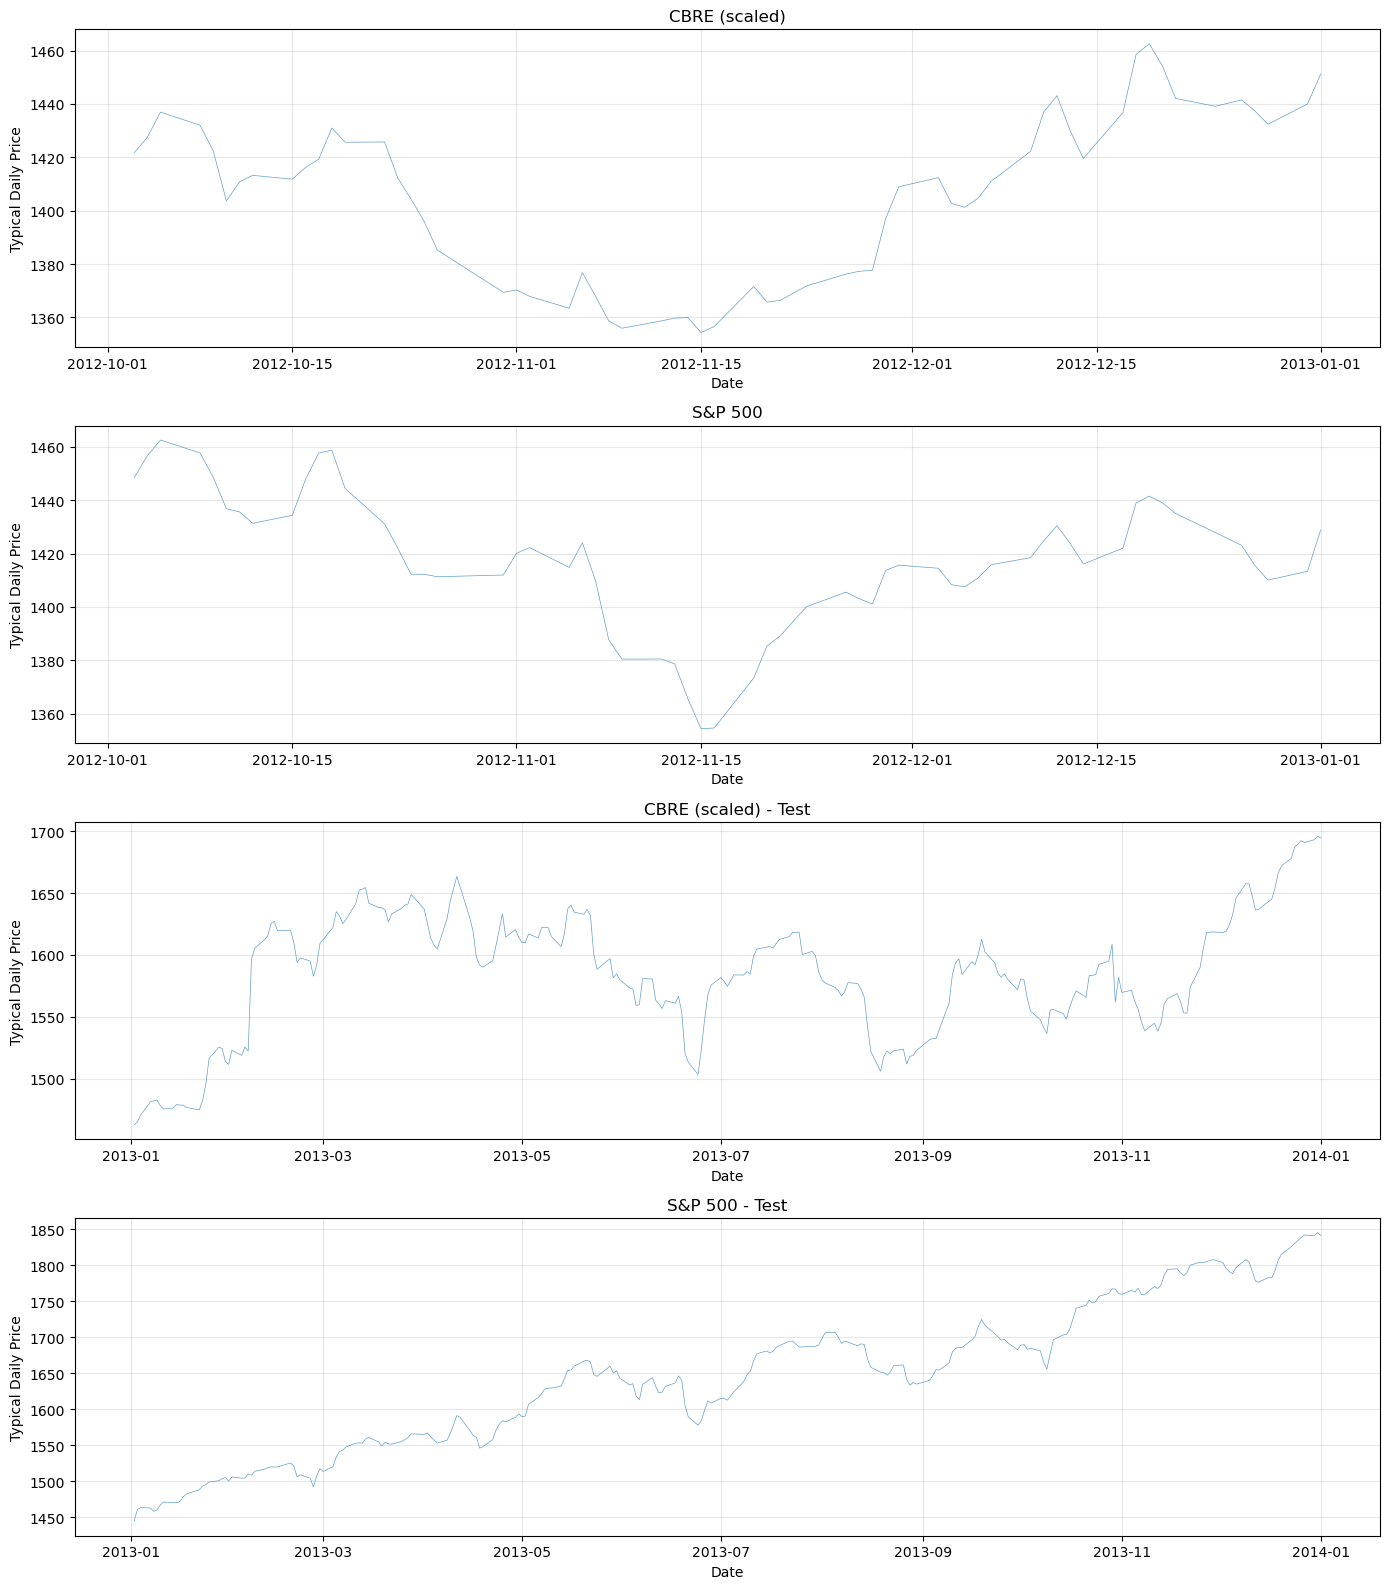

In [211]:
smp_min, smp_max = smp_train.iloc[-91:].y.min(), smp_train.iloc[-91:].y.max()
for series in stocks_train["series"].unique():
    series_mask = stocks_train["series"] == series
    series_min, series_max = (
        stocks_train.loc[series_mask, "y"].min(),
        stocks_train.loc[series_mask, "y"].max(),
    )
    # Scale the stock series to match the S&P 500 range
    stocks_train.loc[series_mask, "y"] = (
        stocks_train.loc[series_mask, "y"] - series_min
    ) / (series_max - series_min) * (smp_max - smp_min) + smp_min

    series_mask = stocks_test["series"] == series
    # Scale the stock series to match the S&P 500 range
    stocks_test.loc[series_mask, "y"] = (
        stocks_test.loc[series_mask, "y"] - series_min
    ) / (series_max - series_min) * (smp_max - smp_min) + smp_min

# plot one stock to check the scaling
plot_dfs(
    [
        stocks_train[stocks_train["series"] == "CBRE"],
        smp_train[-91:],
        stocks_test[stocks_test["series"] == "CBRE"],
        smp_test,
    ],
    ["CBRE (scaled)", "S&P 500", "CBRE (scaled) - Test", "S&P 500 - Test"],
)

## 1.2 Transfer learning feasibility analysis

Before we proceed with building our forecasting models, we need to analyze the feasibility of transfer learning from the S&P 500 Index to the constituent stocks. This involves examining the relationships between the S&P 500 Index and the individual stocks, as well as assessing the patterns and trends in the data.

The approach we take is fitting a hierarchical model on the S&P 500 Index data together with the constituent stock data. This will allow us to check if the the posterior distributions of the parameters are similar across the S&P 500 Index and the constituent stocks, which is a key requirement for successful transfer learning. If the parameters are similar, it indicates that the patterns learned from the S&P 500 Index can be effectively transferred to the constituent stocks, improving our forecasting performance despite the limited training data for the stocks.

We will assume that the slope of the linear trend should be transferable from the S&P 500 Index to the constituent stocks, as they are likely to share similar overall market trends, i.e. when the S&P 500 Index goes up, the constituent stocks are likely to go up as well. However, the yearly seasonality patterns may not be transferable, as different stocks may have different seasonal behaviors based on their industry, market conditions, and other factors.

For this notebook, we will choose a subset of the available constituent stocks to work with, in order to keep the computational requirements manageable. We will select every 10th stock from the list of available constituent stocks, which will give us a representative sample while still allowing us to efficiently train our models.

In [212]:
train_df = pd.concat([smp_train, stocks_train], ignore_index=True)
ticker_series = train_df["series"].unique()
mini_train_df = train_df[train_df["series"].isin(ticker_series[::10])]
print(mini_train_df["series"].unique())
mini_train_df

<StringArray>
['^GSPC',  'ADSK',  'AMAT',  'APTV',  'BBBY',   'BMY',  'CBRE', 'CMCSA',
   'COR',  'CTSH',  'DLTR',   'ECL',   'EQR',  'FAST',   'FMC',   'GLW',
  'HBAN',   'HSY',   'ITW',   'KMB',   'LHX',    'MA',  'META',  'MSFT',
   'NFX',  'NVDA',  'PCAR',   'PLD',   'PSX',   'RRC',   'SNA',   'SYK',
   'TJX',   'UAA',   'VMC',   'WFC',   'XOM']
Length: 37, dtype: str


,ds,series,y
0,2011-01-03,^GSPC,1265.820007
1,2011-01-04,^GSPC,1269.982483
2,2011-01-05,^GSPC,1272.082520
3,2011-01-06,^GSPC,1274.685028
4,2011-01-07,^GSPC,1271.109985
...,...,...,...
33485,2012-12-28,XOM,1354.352509
33486,2012-12-29,XOM,1354.853000
33487,2012-12-30,XOM,1355.353492
33488,2012-12-31,XOM,1355.853984


We now train our hierarchical model on the S&P 500 Index data together with the constituent stock data, and analyze the posterior distributions of the parameters to assess the feasibility of transfer learning.

Output()

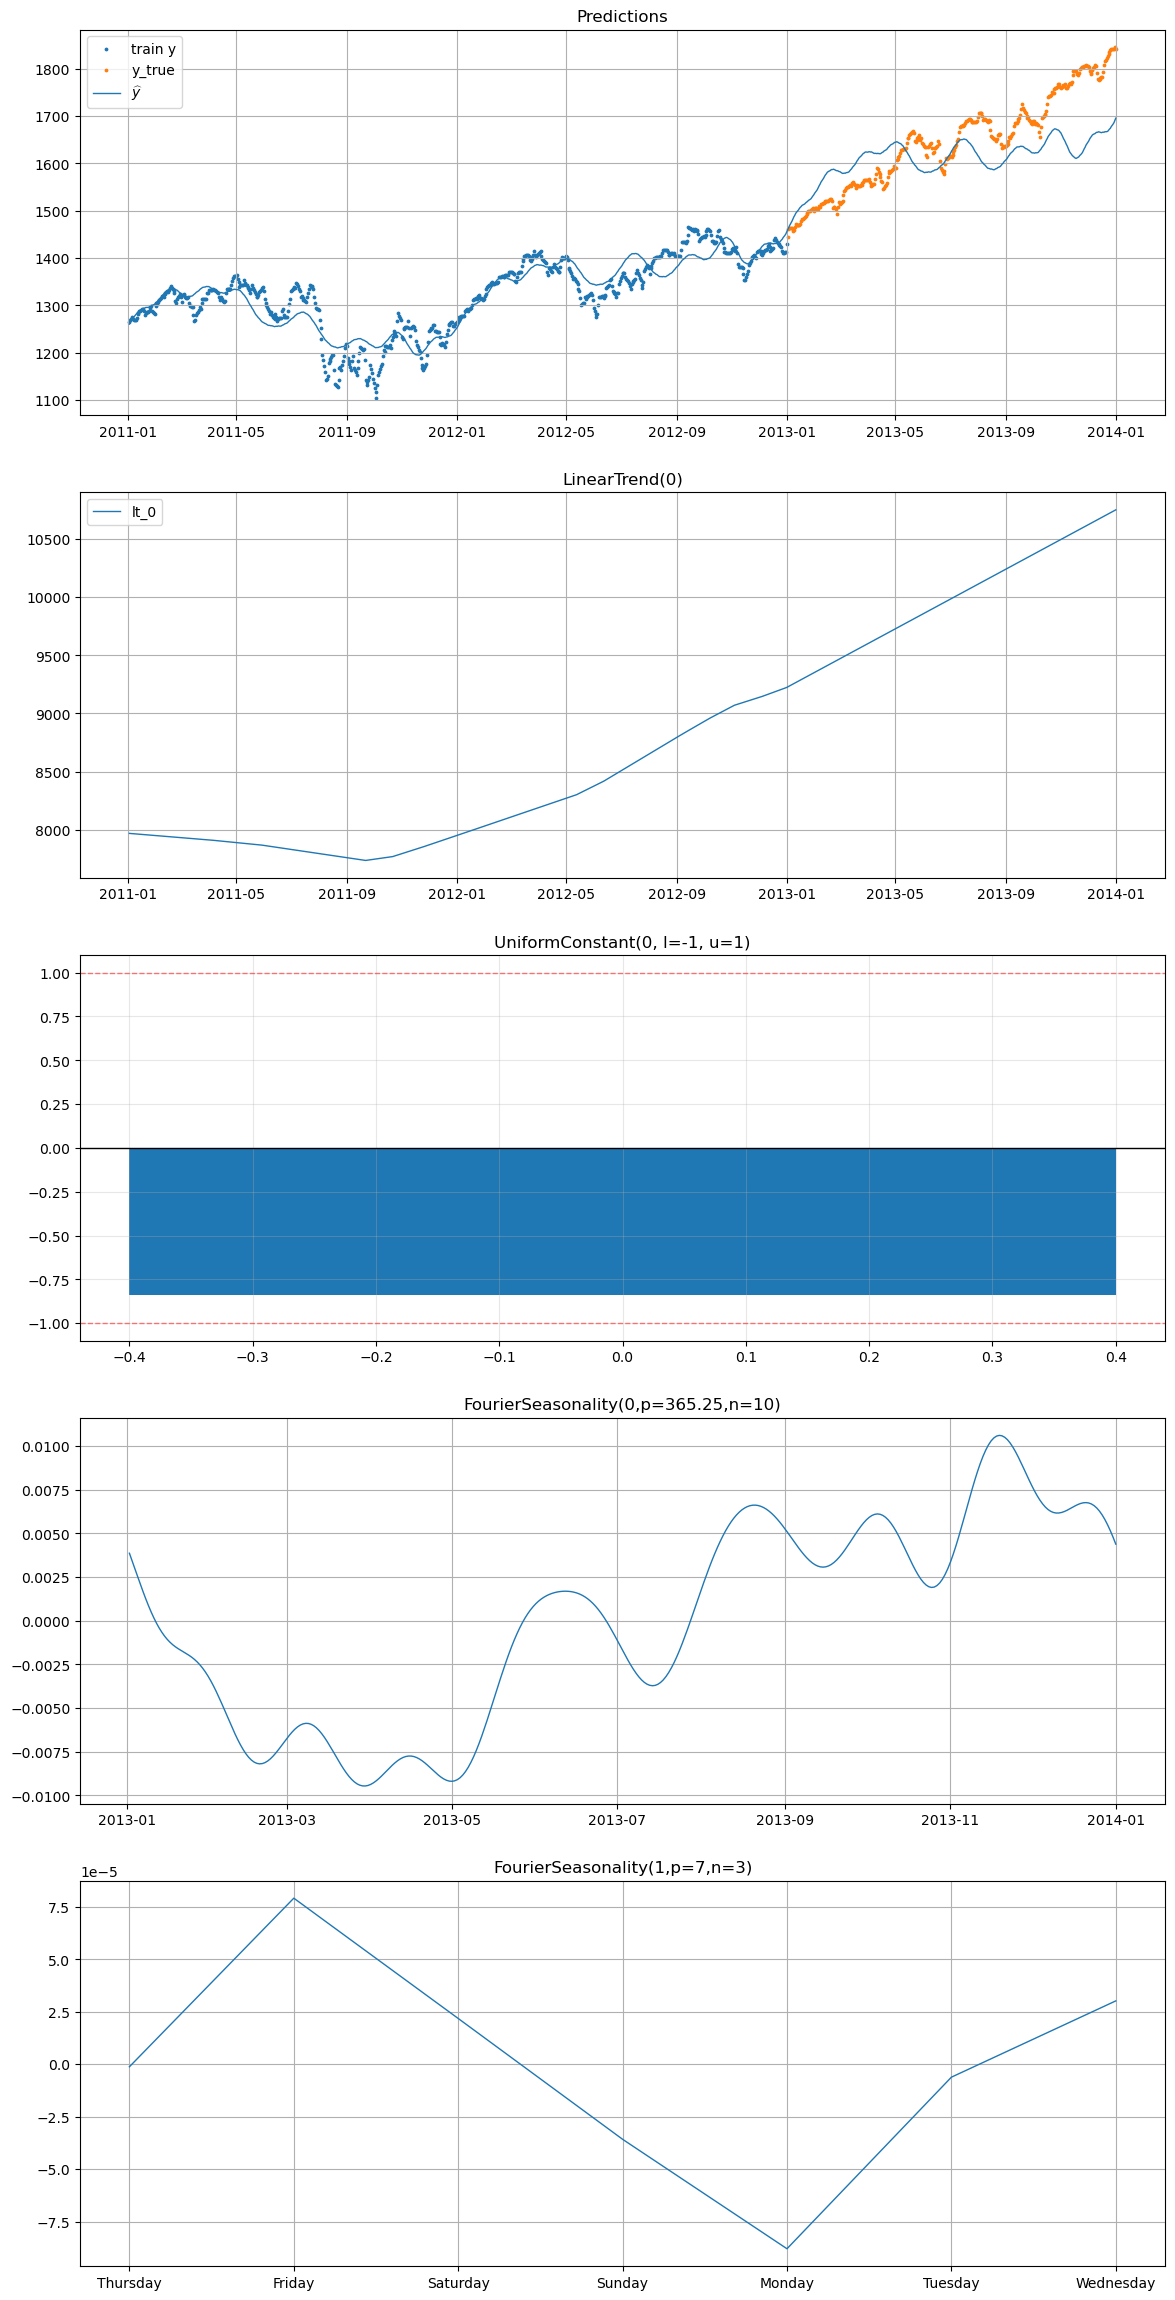

In [237]:
model = LinearTrend(
    n_changepoints=25,
    changepoint_range=1,
    slope_sd=5,
    intercept_sd=5,
    delta_side="right",
    pool_type="partial",
    delta_pool_type="complete",
    tune_method=None,
    delta_tune_method=None,
    shrinkage_strength=10,
) ** (
    UniformConstant(lower=-1, upper=1, pool_type="individual")
    ** FourierSeasonality(
        period=365.25,
        series_order=10,
        beta_sd=10,
        pool_type="partial",
        tune_method=None,
        shrinkage_strength=1000,
    )
    + FourierSeasonality(
        period=7, series_order=3, beta_sd=10, pool_type="individual", tune_method=None
    )
)
model.fit(
    data=mini_train_df,
    scaler="maxabs",
    scale_mode="complete",
    sigma_pool_type="individual",
    method="mapx",
)
yhat = model.predict(365)
model.plot(future=yhat, series="^GSPC", y_true=smp_test)

In [238]:
full_metrics = metrics(
    pd.concat(
        [smp_test, stocks_test[stocks_test["series"].isin(ticker_series[::10])]],
        ignore_index=True,
    ),
    yhat,
    pool_type="individual",
)
print(full_metrics.mean())
full_metrics

mse     51855.672837
rmse      196.524370
mae       164.761998
mape        0.103908
dtype: float64


,mse,rmse,mae,mape
ADSK,116072.893260,340.694722,286.034898,0.186828
AMAT,9306.783817,96.471674,73.493519,0.041380
APTV,75616.231899,274.984058,227.728578,0.133947
BBBY,49212.563534,221.839049,183.982081,0.114887
BMY,88369.410802,297.269929,272.866469,0.145615
CBRE,63169.006982,251.334452,206.183189,0.129928
CMCSA,10875.460577,104.285476,85.745964,0.050904
COR,28433.525602,168.622435,136.066138,0.073622
CTSH,102960.720084,320.874929,281.781243,0.188886
DLTR,4995.906123,70.681724,47.714040,0.031459


In [239]:
beta_shared = model.map_approx["fs_0 - beta_shared"]
beta_z_offset = model.map_approx['fs_0 - beta_z_offset(p=365.25,n=10)']
beta_sigma = model.map_approx["fs_0 - beta_sigma(p=365.25,n=10)"]
# fs = beta_shared + beta_z_offset * beta_sigma
fs = beta_z_offset * beta_sigma
fs_norm = fs / ((fs**2).sum(axis=1) ** 0.5)[:, None]
fs_sim: np.ndarray = fs_norm @ fs_norm.T
# fs_sim = fs @ fs.T
# fs_sim[np.diag_indices(10)] = 0
fs_sorted = fs_sim.argsort(axis=1)
model.groups_[fs_sorted[model.n_groups - 1][-2].item()], model.groups_[
    fs_sorted[model.n_groups - 1][0].item()
], model.groups_[np.abs(fs_sim).argmin(axis=1)[model.n_groups - 1].item()]

('NFX', 'WFC', 'FAST')

In [242]:
[model.groups_[key] for key in fs_sorted[model.n_groups - 1]]

['WFC',
 'SYK',
 'ADSK',
 'CBRE',
 'VMC',
 'FMC',
 'CTSH',
 'DLTR',
 'TJX',
 'GLW',
 'LHX',
 'META',
 'AMAT',
 'NVDA',
 'HBAN',
 'PLD',
 'BMY',
 'MA',
 'FAST',
 'APTV',
 'PSX',
 'KMB',
 'HSY',
 'CMCSA',
 'UAA',
 'ITW',
 'EQR',
 'PCAR',
 'COR',
 'XOM',
 'BBBY',
 'SNA',
 'ECL',
 'RRC',
 'MSFT',
 'NFX',
 '^GSPC']

In [240]:
good_metrics = []
bad_metrics = []

for cutoff in range(1, 15):
    good_series = [model.groups_[key] for key in fs_sorted[model.n_groups - 1][-cutoff:]]
    bad_series = [model.groups_[key] for key in fs_sorted[model.n_groups - 1][:cutoff]]
    # print(good_series, bad_series)
    good_metrics.append(full_metrics[full_metrics.index.isin(good_series)].mape.mean().item())
    bad_metrics.append(full_metrics[full_metrics.index.isin(bad_series)].mape.mean().item())

print(len(good_metrics), len(bad_metrics))
print(good_metrics)
print(bad_metrics)

14 14
[0.039557368356287724, 0.07535023936730928, 0.08515078440899894, 0.0764568493460656, 0.07858645493006418, 0.08759053609200101, 0.09149001013474242, 0.08399169665417415, 0.08283947034222591, 0.08982228111156723, 0.09575273803423151, 0.0908100084000269, 0.08773851054606688, 0.08510744892762565]
[0.03121782790916749, 0.04860711614021201, 0.09468083328209347, 0.10349261414013827, 0.14266372580939687, 0.1408831679131395, 0.14774065219001037, 0.1332054691350217, 0.1210667063561581, 0.11846479784882329, 0.11740495565551362, 0.12659471894807273, 0.12003971452697094, 0.11488313030668608]


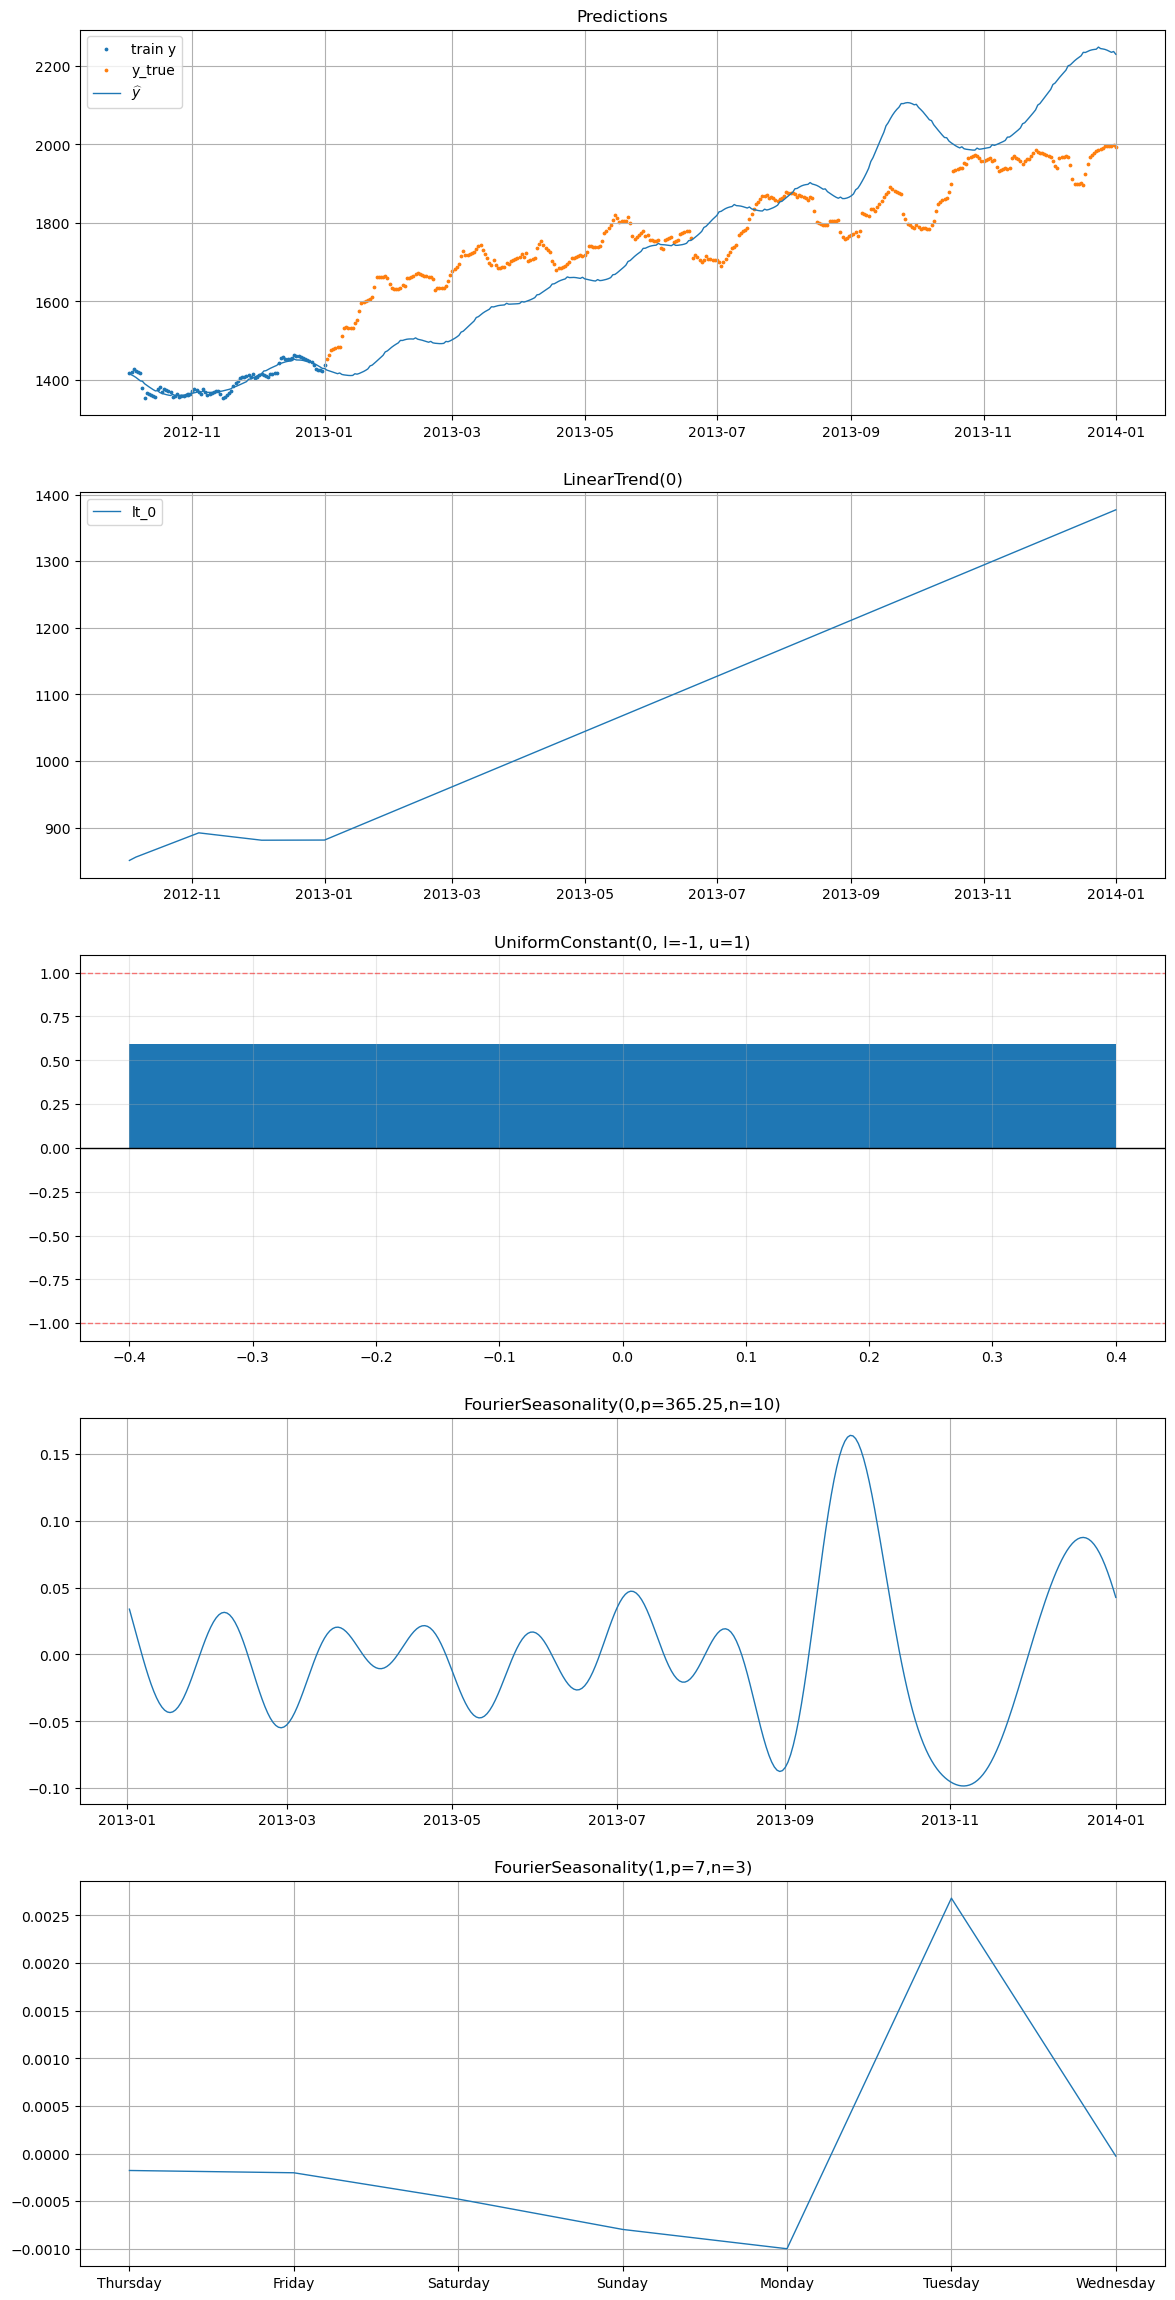

In [247]:
model.plot(future=yhat, series="SYK", y_true=stocks_test[stocks_test["series"] == "SYK"])
# model.plot(future=yhat, series="^GSPC", y_true=smp_test)

In [86]:
fs = model.map_approx["fs_0 - beta(p=365.25,n=10)"]
fs_norm = fs / ((fs**2).sum(axis=1) ** 0.5)[:, None]
fs_sim: np.ndarray = fs_norm @ fs_norm.T
# fs_sim[np.diag_indices(10)] = 0
fs_sorted = fs_sim.argsort(axis=1)
model.groups_[fs_sorted[model.n_groups - 1][-2].item()], model.groups_[
    fs_sorted[model.n_groups - 1][0].item()
], model.groups_[np.abs(fs_sim).argmin(axis=1)[model.n_groups - 1].item()]

('WFC', 'KMB', 'DLTR')

In [75]:
fs_sim.argmax(axis=0)[0].item(), model.n_groups

(0, 37)

In [101]:
fs_sim.max(axis=0)[model.n_groups - 1], fs_sim.min(axis=0)[model.n_groups - 1], np.abs(
    fs_sim
).min(axis=0)[model.n_groups - 1], fs_sim[model.n_groups - 1] >= 0.85, fs_sim[
    model.n_groups - 1
]

(np.float64(1.0),
 np.float64(-0.5607517165167293),
 np.float64(0.02834703623100874),
 array([False, False, False, False, False, False,  True, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False, False,  True,
        False, False, False, False, False, False, False,  True, False,
         True]),
 array([ 0.63592767,  0.82493434,  0.8346767 , -0.40234941, -0.23290729,
         0.11116529,  0.86892506,  0.50100421,  0.70967462, -0.02834704,
         0.25287525,  0.2278343 ,  0.79665051,  0.72508128,  0.50298011,
         0.50954763, -0.45023116,  0.82133821, -0.56075172,  0.47106422,
         0.47456315,  0.07898832,  0.87766915,  0.11649221,  0.42379032,
         0.51296569,  0.86733195, -0.22171583, -0.23567874,  0.73818402,
         0.55270027,  0.06416785,  0.09671364,  0.6421698 ,  0.91095454,
         0.54775366,  1.        ]))

In [103]:
model.groups_[6], fs_sim[model.n_groups - 1][6]

('CMCSA', np.float64(0.8689250633641628))

In [32]:
fs.shape

(37, 20)

In [38]:
fs_sim / ((fs ** 2).sum(axis=1) ** 0.5)

array([[ 0.        ,  0.46454411,  0.35578099, ...,  0.37282271,
        -0.10821168,  0.32447005],
       [ 0.57215282,  0.        ,  0.53526192, ...,  0.55258724,
         0.02377892,  0.51840761],
       [ 0.45732682,  0.5586312 ,  0.        , ...,  0.50711883,
         0.20576751,  0.54743066],
       ...,
       [ 0.18828963,  0.22658951,  0.19924611, ...,  0.25768607,
         0.06474965,  0.23474029],
       [-0.03631615,  0.00647937,  0.05372278, ...,  0.04302679,
         0.17123498,  0.09379459],
       [ 0.12163299,  0.15778403,  0.15964744, ...,  0.17423699,
         0.10476807,  0.19126859]], shape=(37, 37))

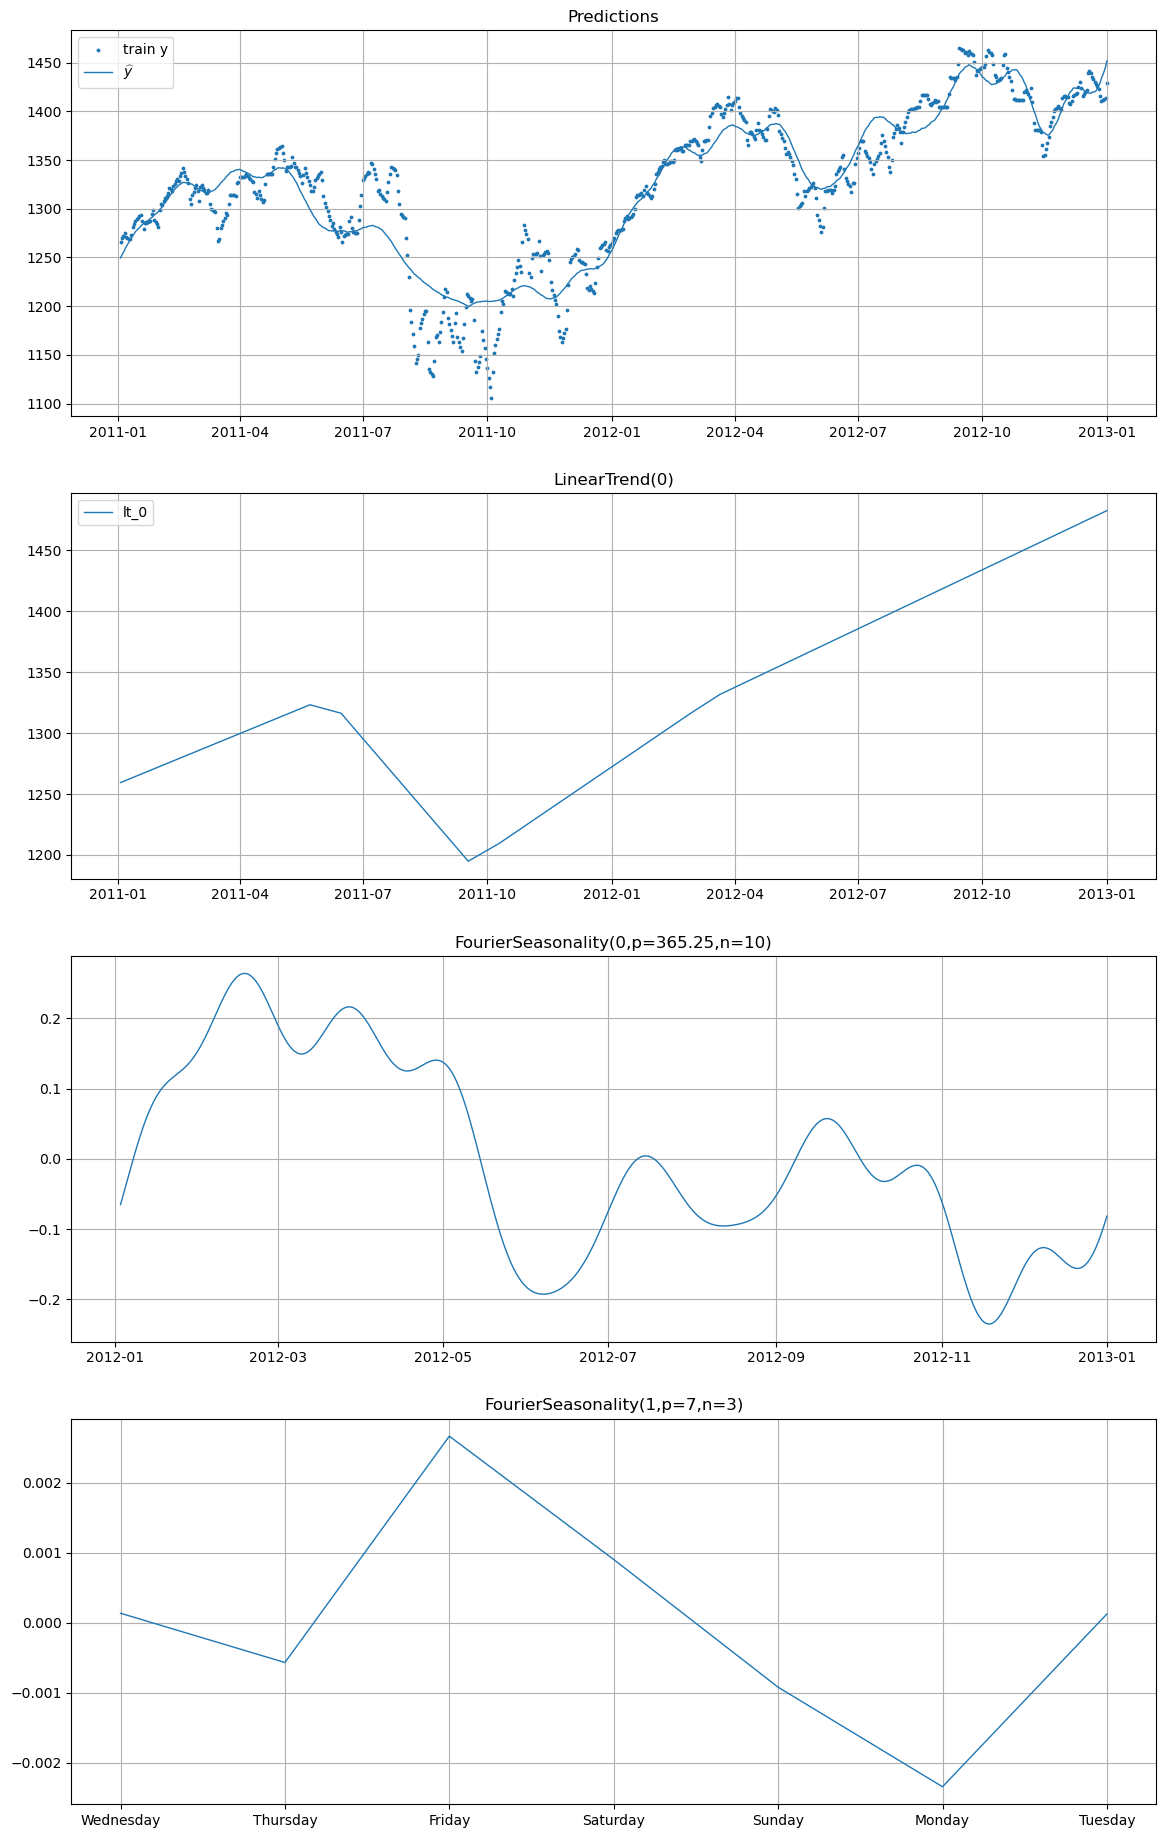

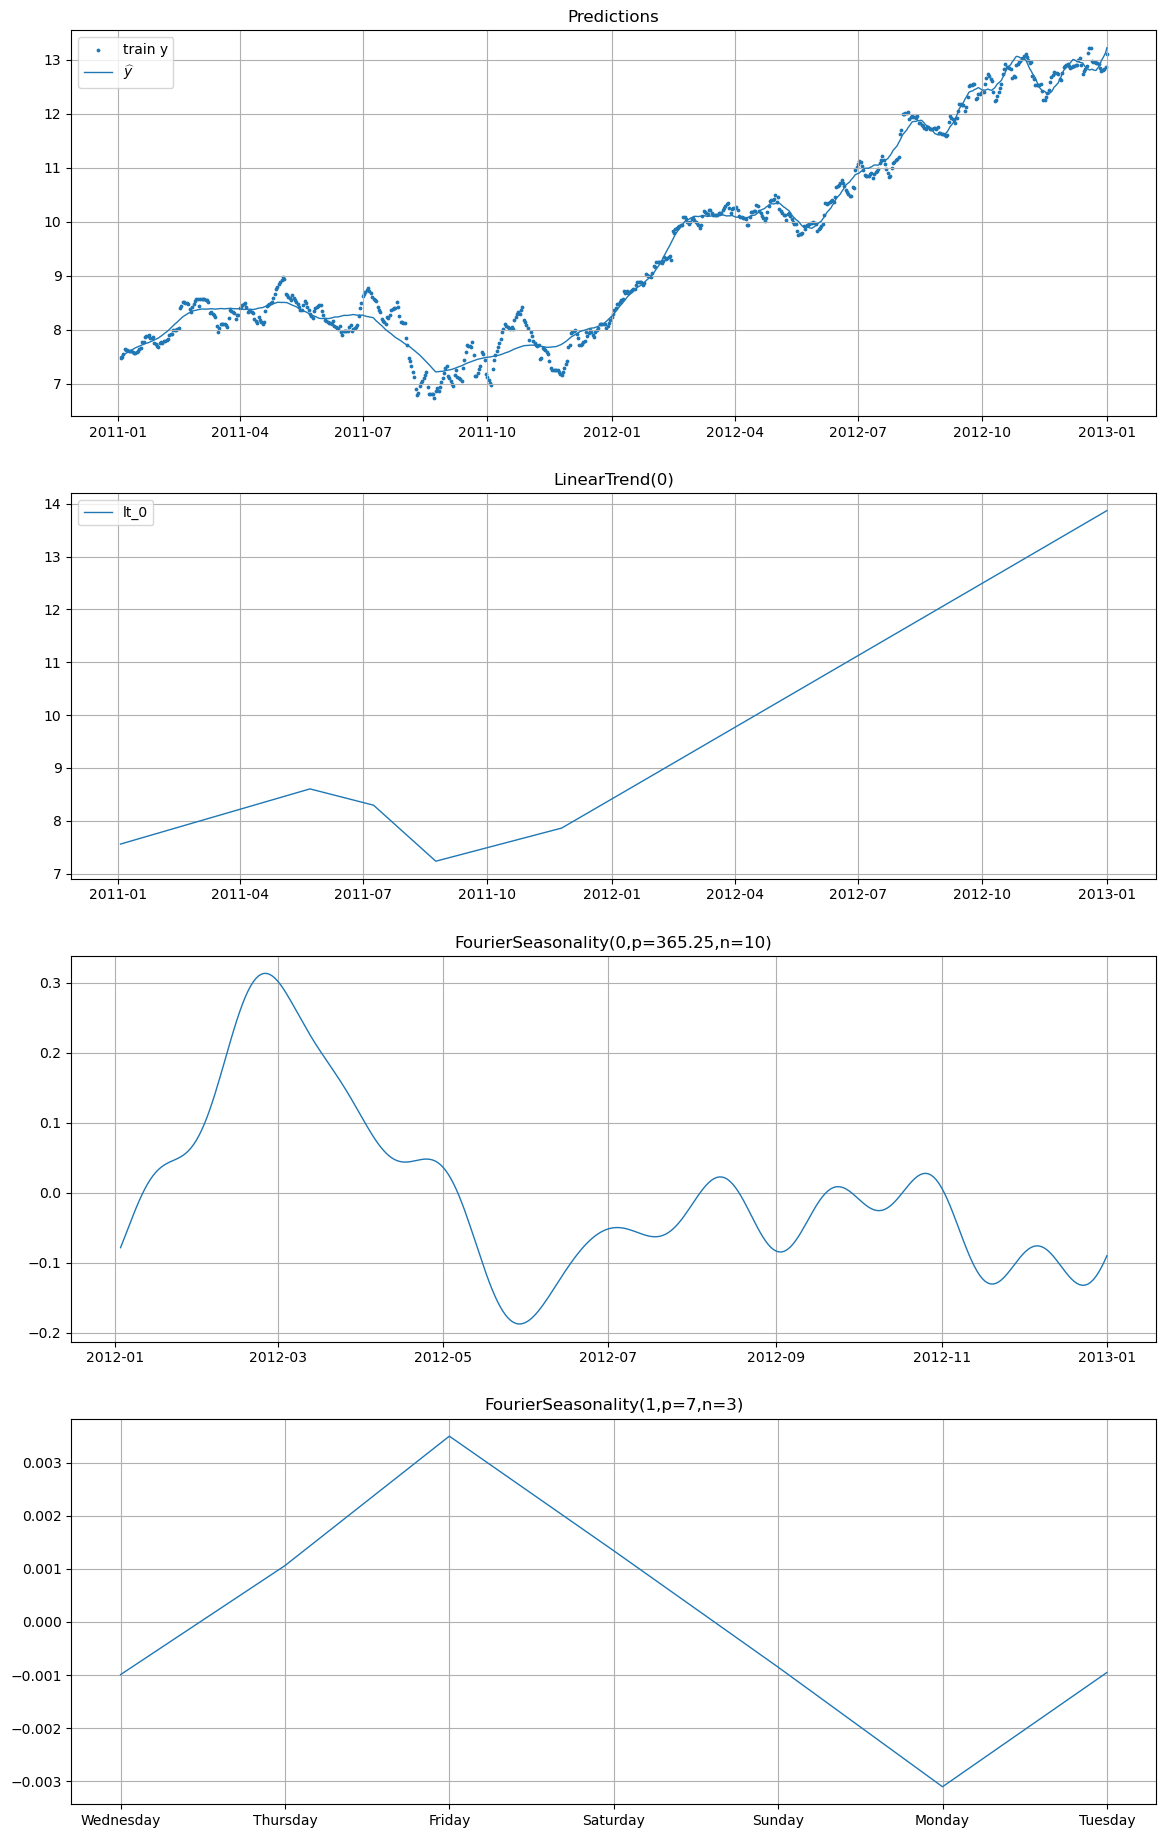

In [104]:
# yhat = model.predict(horizon=365)
model.plot(future=yhat, series="^GSPC")
model.plot(future=yhat, series="CMCSA")
# model.plot(future=yhat, series="KMB")
# model.plot(future=yhat, series="DLTR")
# model.plot(future=yhat, series="PSX")

## 1.3 Data visualization

Let's plot the S&P 500 Index data and a few constituent stocks to visualize the trends and patterns in the data. This will help us understand the characteristics of the time series we are working with and identify any potential challenges in modeling.

          ds            y  log_return  volatility
0 2013-01-02  1444.307495         NaN         NaN
1 2013-01-03  1460.697510    0.011284         NaN
2 2013-01-04  1463.192474    0.001707         NaN
3 2013-01-05  1463.082479   -0.000075         NaN
4 2013-01-06  1462.972483   -0.000075         NaN
              ds          y  log_return  volatility
90378 2013-01-02  28.490324         NaN         NaN
90379 2013-01-03  28.571174    0.002834         NaN
90380 2013-01-04  28.649932    0.002753         NaN
90381 2013-01-05  28.607783   -0.001472         NaN
90382 2013-01-06  28.565635   -0.001474         NaN
             ds          y  log_return  volatility
1460 2013-01-02  38.227499         NaN         NaN
1461 2013-01-03  37.962500   -0.006956         NaN
1462 2013-01-04  37.955000   -0.000198         NaN
1463 2013-01-05  37.941667   -0.000351         NaN
1464 2013-01-06  37.928333   -0.000351         NaN
              ds         y  log_return  volatility
88918 2013-01-02  0.291342     

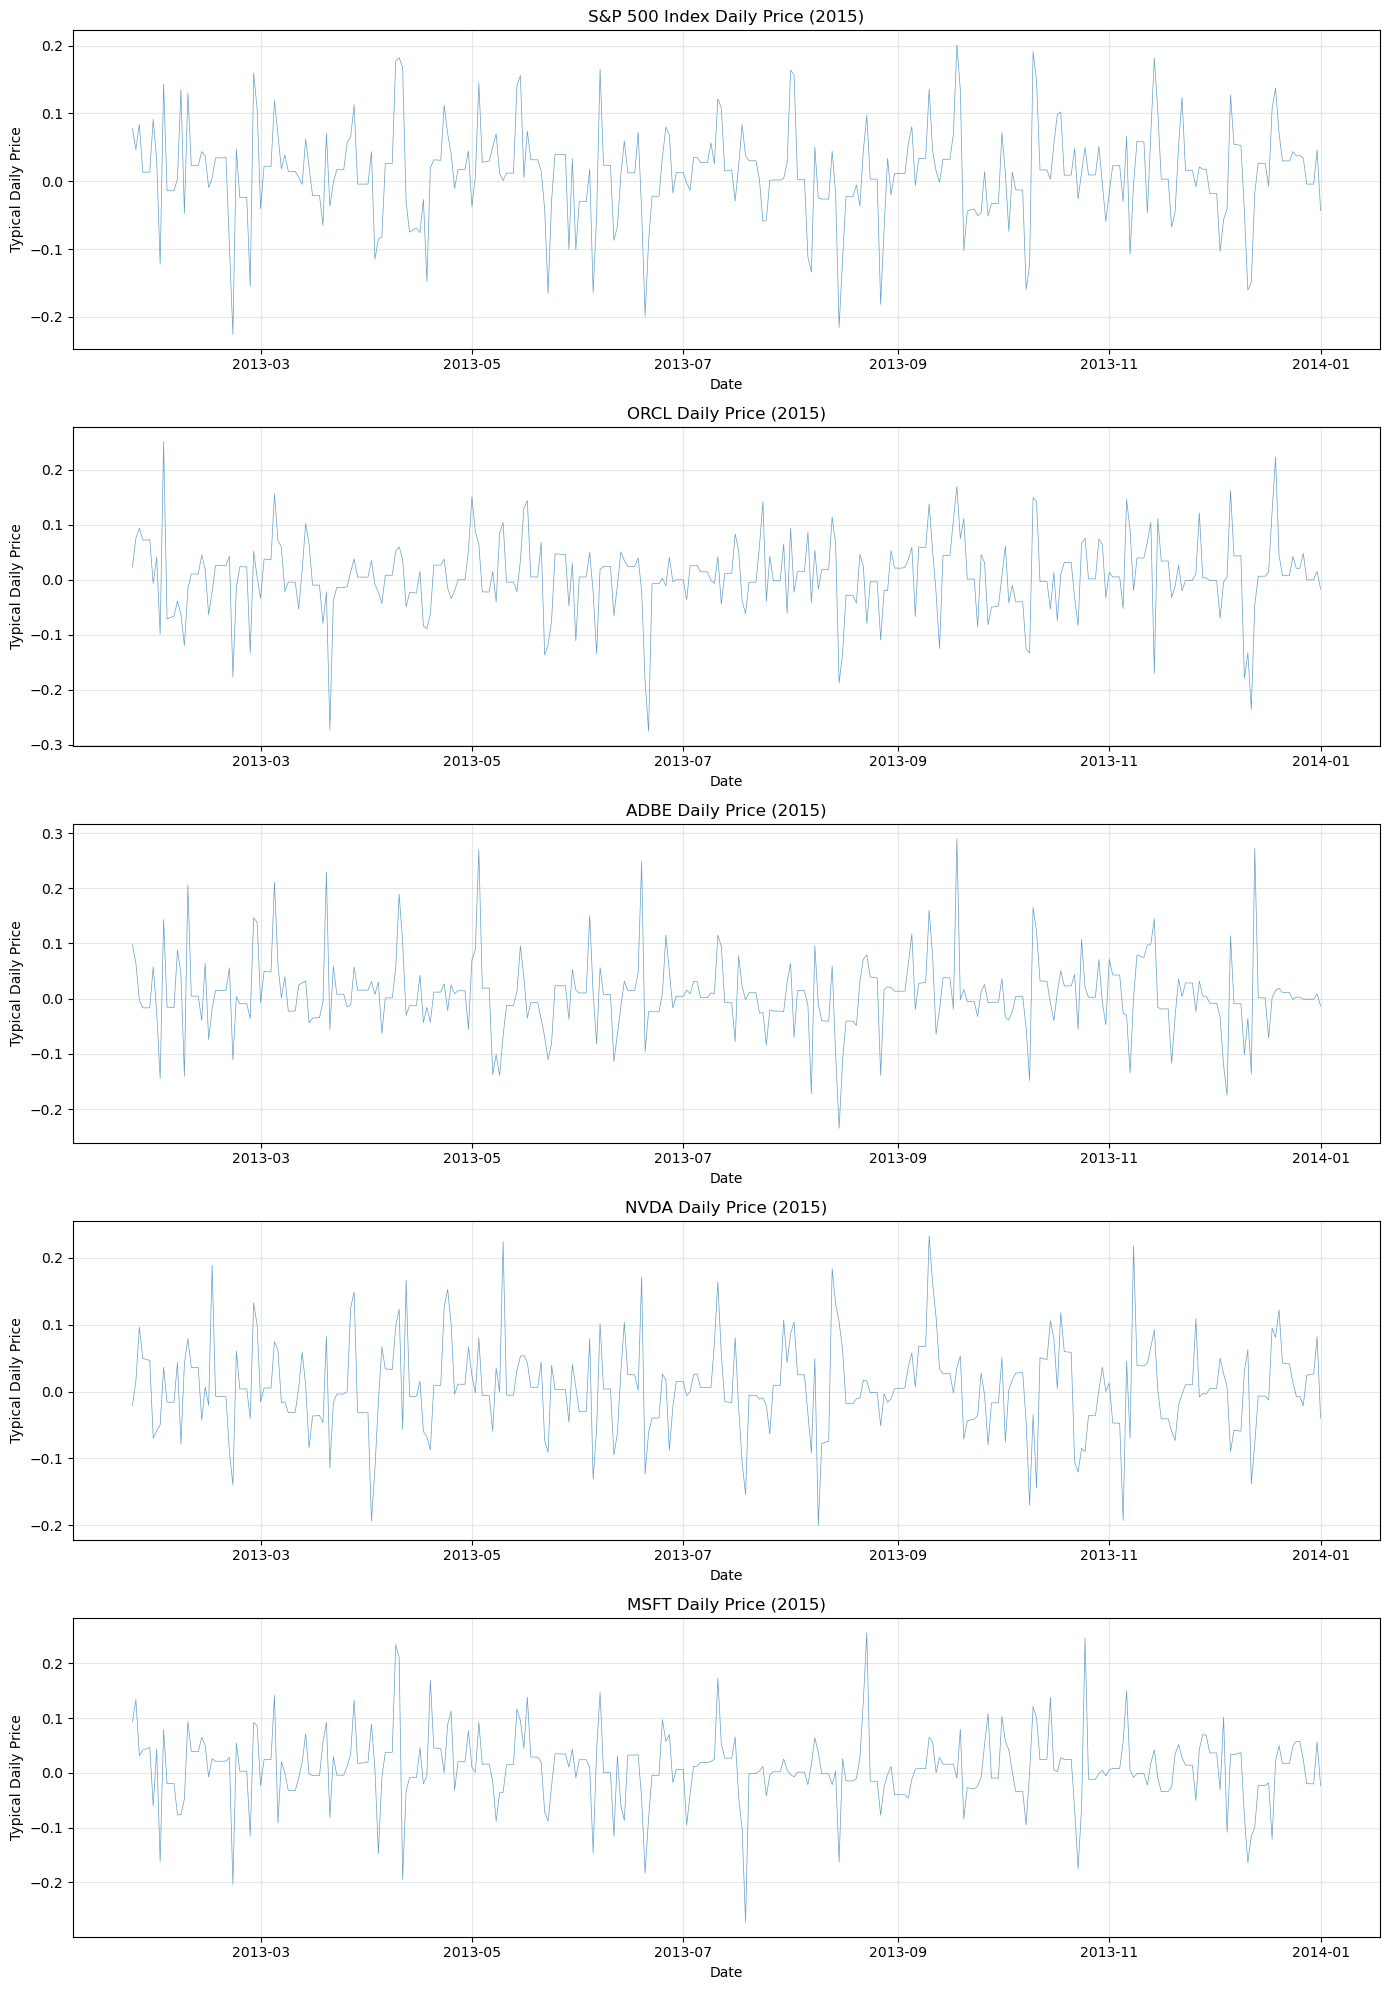

In [44]:
plot_dfs(
    dfs=[
        smp_test,
        stocks_test[stocks_test["series"] == "ORCL"],
        stocks_test[stocks_test["series"] == "ADBE"],
        stocks_test[stocks_test["series"] == "NVDA"],
        stocks_test[stocks_test["series"] == "MSFT"],
    ],
    titles=[
        "S&P 500 Index Daily Price (2015)",
        "ORCL Daily Price (2015)",
        "ADBE Daily Price (2015)",
        "NVDA Daily Price (2015)",
        "MSFT Daily Price (2015)",
    ]
)

# 2. Training the base S&P 500 Index model

1. Linear Trend
    - slope: $ k \sim  \mathcal{N}(0, 5) $
    - intercept: $ m \sim  \mathcal{N}(0, 5) $
    - changepoints: 25, with $ \delta \sim  \mathcal{Laplace}(0, 0.05) $
2. Yearly seasonality
    - Fourier order 10
    - $ \beta_y \sim  \mathcal{N}(0, 10) $
3. Weekly seasonality
    - Fourier order 3
    - $ \beta_w \sim  \mathcal{N}(0, 10) $
4. Error term 
    - $ \sigma \sim  \mathcal{HN}(0, 0.5) $

$ y = \text{trend} \cdot (1 + \text{yearly seasonality} + \text{weekly seasonality}) + \text{error} $

In [3]:
smp_model_default = LinearTrend(n_changepoints=5) ** (
    FourierSeasonality(period=365, series_order=10)
    + FourierSeasonality(period=7, series_order=3)
)
smp_model_default.fit(smp[0], scaler="minmax", method="nuts")
smp_prior_predictive_default = smp_model_default.sample_prior_predictive(samples=1000)
smp_posterior_predictive_default = smp_model_default.sample_posterior_predictive()

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lt_0 - slope, lt_0 - intercept, lt_0 - delta, fs_0 - beta(p=365,n=10), fs_1 - beta(p=7,n=3), sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 416 seconds.
Sampling: [fs_0 - beta(p=365,n=10), fs_1 - beta(p=7,n=3), lt_0 - delta, lt_0 - intercept, lt_0 - slope, obs, sigma]
Sampling: [obs]


Output()

Let's see how the prior predictive looks like with these default settings.

<Axes: title={'center': 'Prior Predictive Check'}, xlabel='t', ylabel='y'>

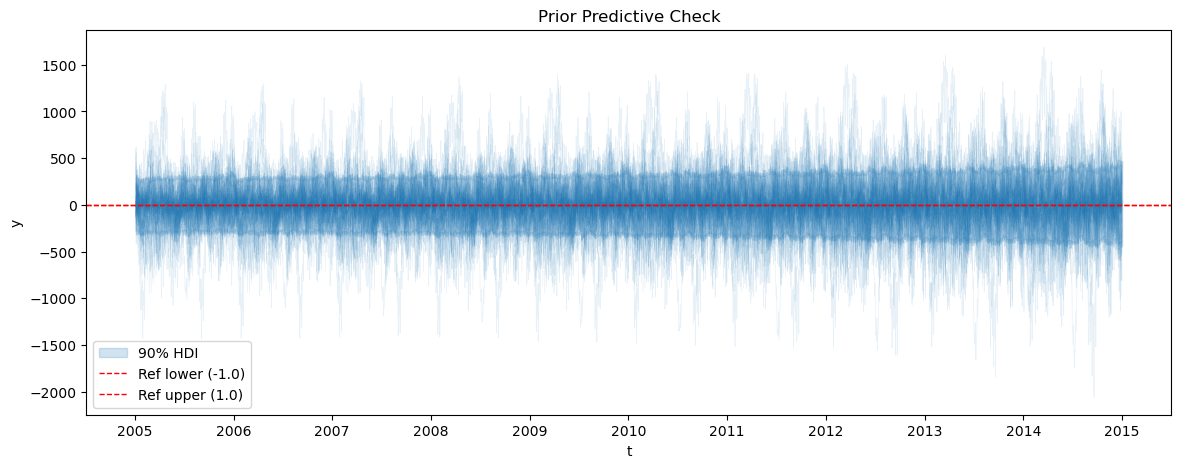

In [4]:
plot_prior_predictive(
    smp_prior_predictive_default,
    smp_model_default.data,
    show_hdi=True,
    show_ref_lines=True,
    t=smp_model_default.data["ds"],
)

From the prior predictive, we can see that the default settings are not very good for this dataset. The prior predictive is too wide and does not capture the trend and seasonality of the data. The coverage of the prior predictive is also very low, which means that the model is not able to capture the true values of the data.

The coverage is calculated as the percentage of the values that fall within -2 and 2.

In [5]:
prior_predictive_coverage(smp_prior_predictive_default)

0.03631534246575342

The posterior predictive is good, even though the priors were too wide.

<Axes: title={'center': 'Posterior Predictive Check'}, xlabel='t', ylabel='y'>

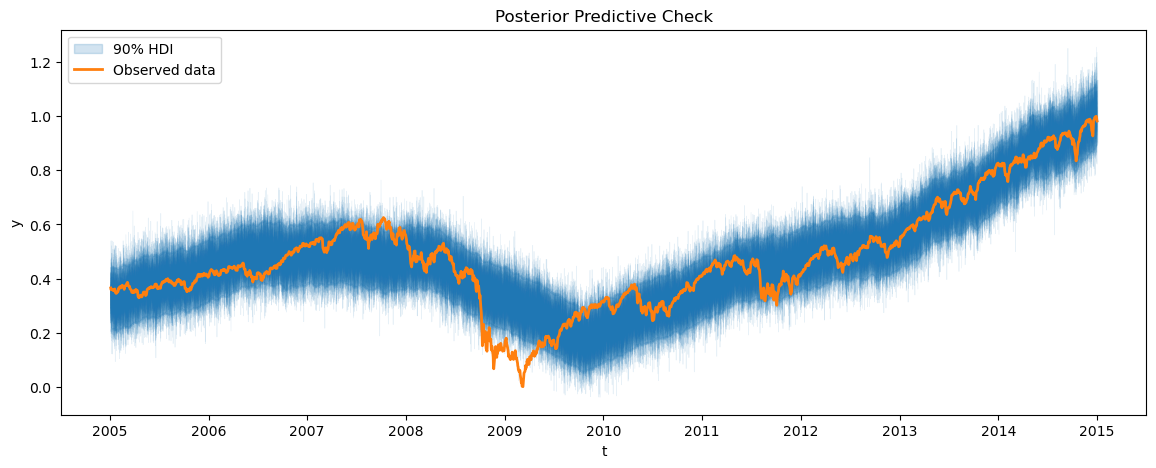

In [6]:
plot_posterior_predictive(
    smp_posterior_predictive_default,
    smp_model_default.data,
    show_hdi=True,
    t=smp_model_default.data["ds"],
)

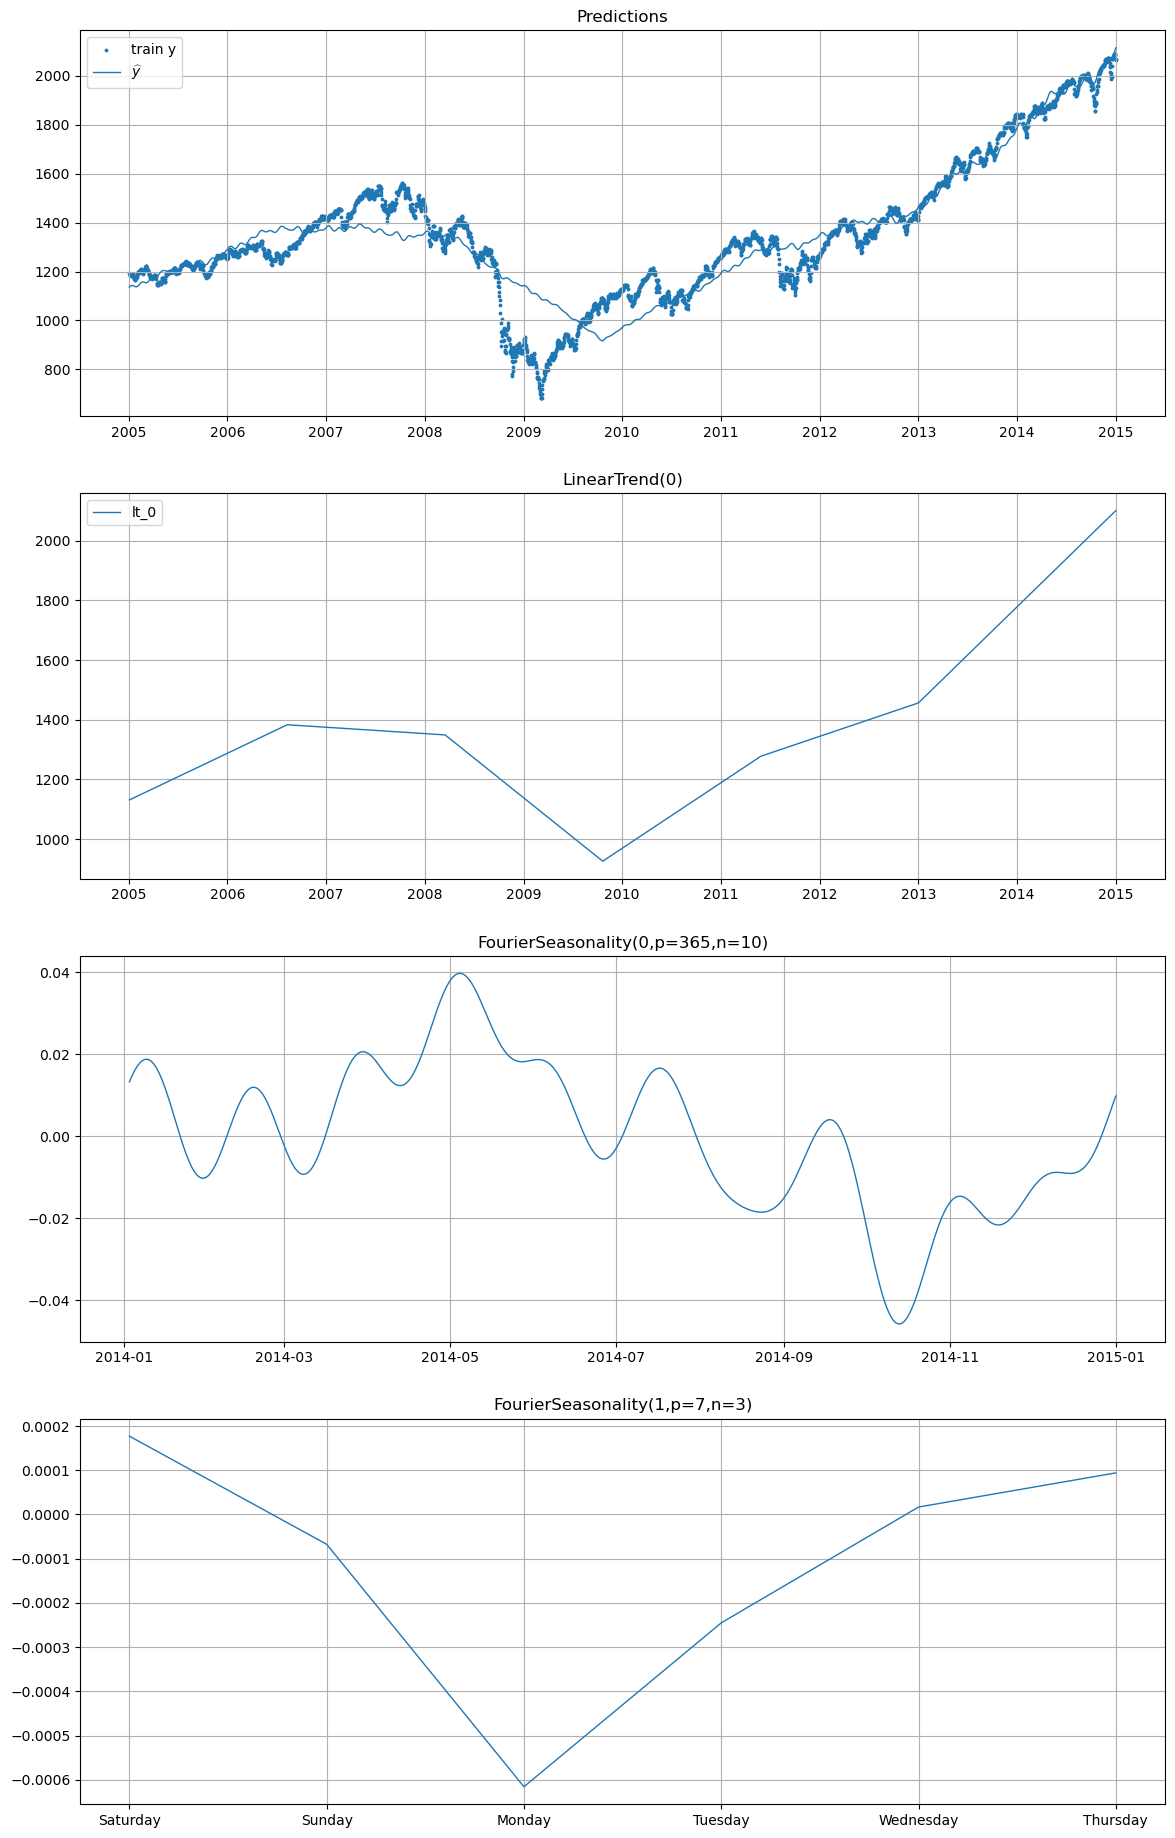

In [7]:
future = smp_model_default.predict(horizon=0)
smp_model_default.plot(future, series="^GSPC")

In [8]:
smp_model_default.convergence_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lt_0 - slope,1.118,0.048,1.028,1.205,0.001,0.001,2017.0,2614.0,1.0
lt_0 - intercept,0.319,0.005,0.310,0.330,0.000,0.000,2594.0,3087.0,1.0
lt_0 - delta[0],-1.269,0.078,-1.415,-1.125,0.002,0.001,1898.0,2505.0,1.0
lt_0 - delta[1],-1.730,0.070,-1.864,-1.600,0.001,0.001,2351.0,2913.0,1.0
lt_0 - delta[2],3.441,0.070,3.316,3.578,0.001,0.001,2401.0,2747.0,1.0
lt_0 - delta[3],-0.766,0.068,-0.892,-0.639,0.001,0.001,2498.0,2770.0,1.0
lt_0 - delta[4],1.494,0.066,1.379,1.628,0.001,0.001,3339.0,3089.0,1.0
"fs_0 - beta(p=365,n=10)[0]",0.017,0.003,0.011,0.023,0.000,0.000,6417.0,3054.0,1.0
"fs_0 - beta(p=365,n=10)[1]",-0.011,0.003,-0.017,-0.005,0.000,0.000,7151.0,3000.0,1.0
"fs_0 - beta(p=365,n=10)[2]",-0.001,0.003,-0.007,0.005,0.000,0.000,8029.0,2661.0,1.0


# Adjusting priors based on prior predictive checks

Prior predictive checks revealed that the default priors were too wide, leading to unrealistic forecasts. To address this, we narrowed the priors for the slope and intercept of the linear trend, as well as the coefficients for the seasonal components.

1. Linear Trend
    - slope: $ k \sim  \mathcal{N}(0, 2) $
    - intercept: $ m \sim  \mathcal{N}(0, 2) $
    - changepoints: 5, with $ \delta \sim  \mathcal{Laplace}(0, 0.05) $
2. Yearly seasonality
    - Fourier order 4
    - $ \beta_y \sim  \mathcal{N}(0, 0.1) $
3. Weekly seasonality
    - Fourier order 2
    - $ \beta_w \sim  \mathcal{N}(0, 0.1) $
4. Error term
    - $ \sigma \sim  \mathcal{HN}(0, 1) $

$ y = \text{linear trend} \cdot (1 + \text{yearly seasonality} + \text{weekly seasonality}) + \text{error} $

In [9]:
smp_model = LinearTrend(
    n_changepoints=5, slope_sd=5, intercept_sd=5, delta_side="right"
) ** (
    FourierSeasonality(period=365, series_order=6, beta_sd=0.5)
    + FourierSeasonality(period=7, series_order=3, beta_sd=0.5)
)
smp_model.fit(smp[0], scaler="minmax", method="nuts")
smp_prior_predictive = smp_model.sample_prior_predictive(samples=1000)
smp_posterior_predictive = smp_model.sample_posterior_predictive()

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lt_0 - slope, lt_0 - intercept, lt_0 - delta, fs_0 - beta(p=365,n=6), fs_1 - beta(p=7,n=3), sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 320 seconds.
Sampling: [fs_0 - beta(p=365,n=6), fs_1 - beta(p=7,n=3), lt_0 - delta, lt_0 - intercept, lt_0 - slope, obs, sigma]
Sampling: [obs]


Output()

We do the prior predictive check again with the adjusted priors and see that the prior predictive is much better. The prior predictive captures the trend and seasonality of the data much better, and the coverage is also much higher.

<Axes: title={'center': 'Prior Predictive Check'}, xlabel='t', ylabel='y'>

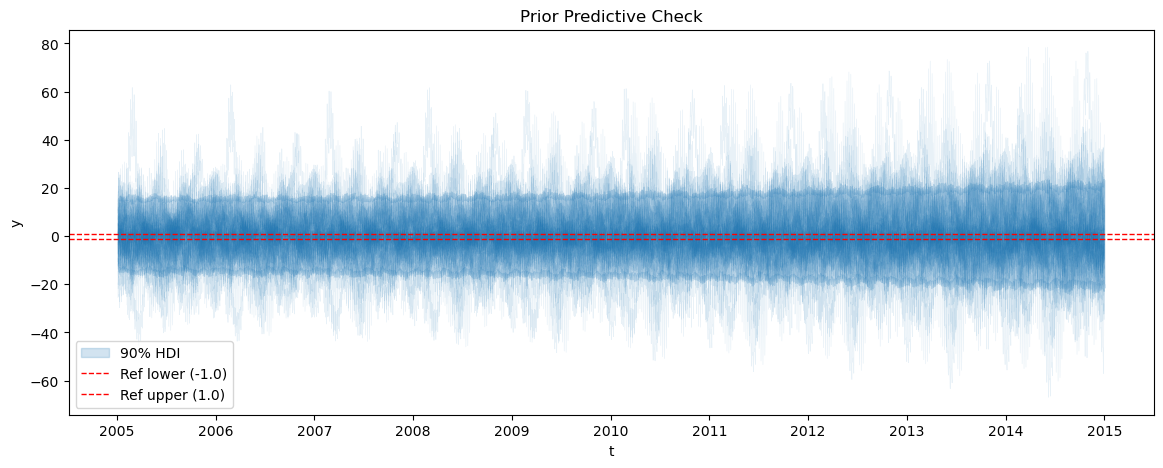

In [10]:
plot_prior_predictive(
    smp_prior_predictive,
    smp_model.data,
    show_hdi=True,
    show_ref_lines=True,
    t=smp_model.data["ds"],
)

In [11]:
prior_predictive_coverage(smp_prior_predictive)

0.32101753424657536

Now we also check the posterior predictive to see how well the model fits the data. The posterior predictive shows that the model is able to capture the trend and seasonality of the data, even though priors are narrower than the default ones. However, the fit is not perfect, as can be seen from the drop in price in Oct 2014 that is not captured by the model.

<Axes: title={'center': 'Posterior Predictive Check'}, xlabel='t', ylabel='y'>

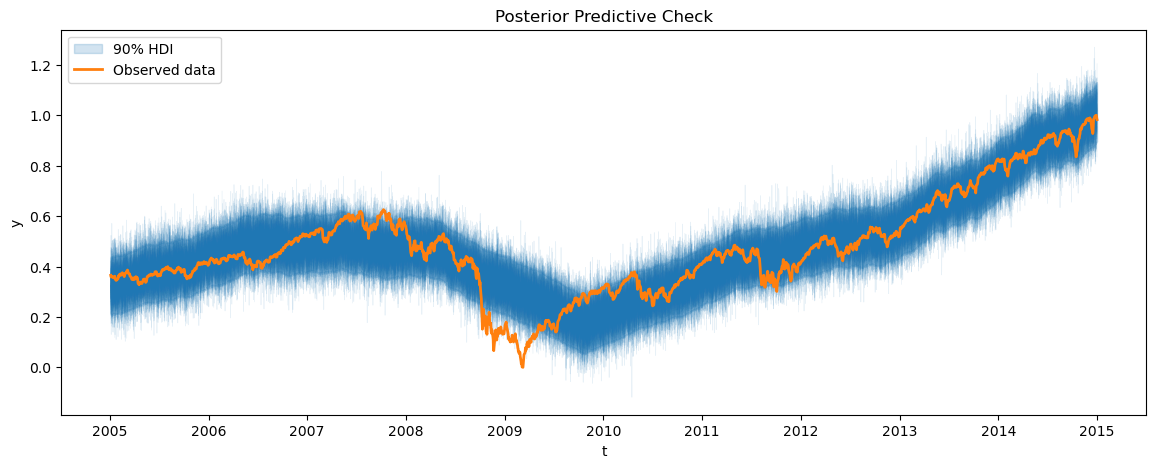

In [12]:
plot_posterior_predictive(
    smp_posterior_predictive,
    smp_model.data,
    show_hdi=True,
    t=smp_model.data["ds"],
)

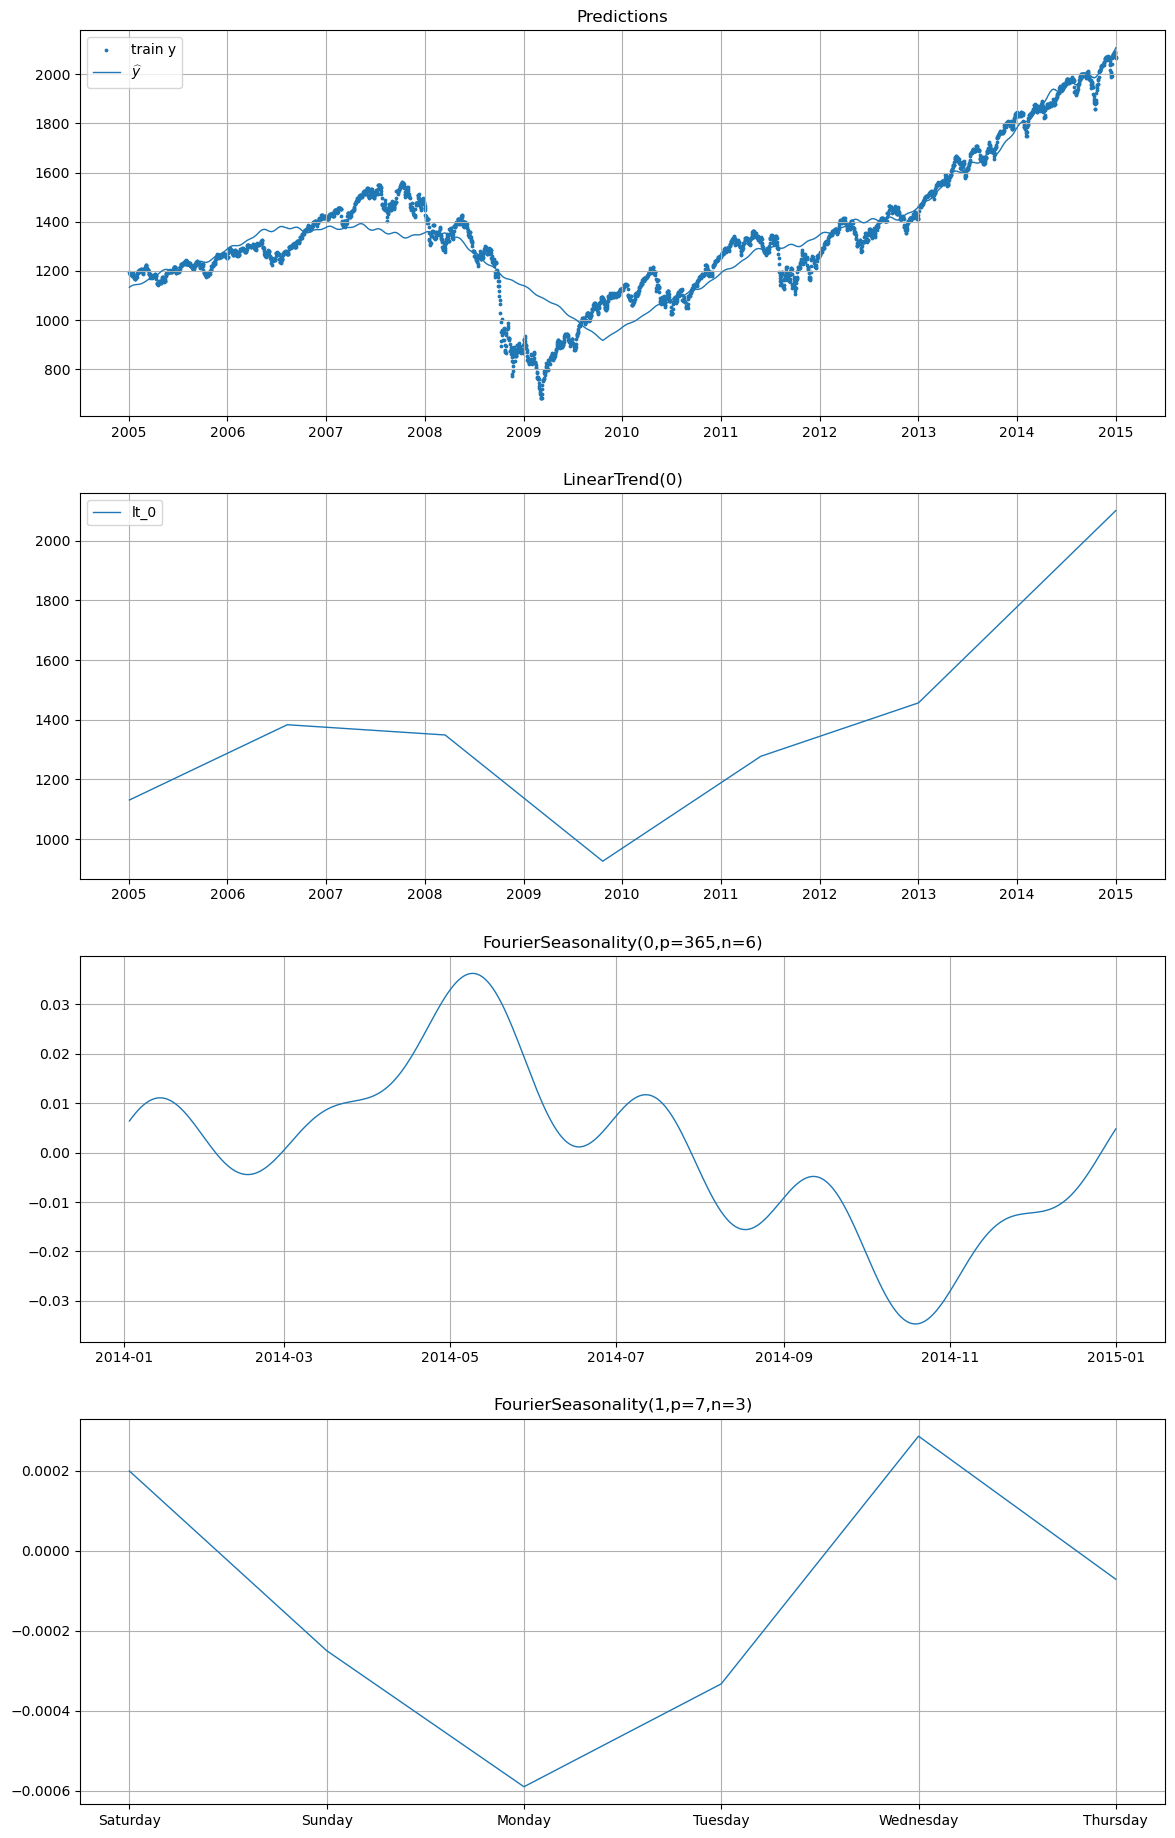

In [13]:
future = smp_model.predict(horizon=0)
smp_model.plot(future, series="^GSPC")

The ESS is also a bit lower than the default model, which is expected since we have narrower priors. However, the Rhat values are all 1, which indicates that the model has converged well.

In [14]:
smp_model.convergence_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lt_0 - slope,2.287,0.036,2.218,2.354,0.001,0.001,2388.0,2660.0,1.00
lt_0 - intercept,-1.279,0.032,-1.339,-1.220,0.001,0.000,2361.0,2679.0,1.00
lt_0 - delta[0],1.271,0.079,1.125,1.424,0.001,0.001,4442.0,3172.0,1.00
lt_0 - delta[1],1.728,0.069,1.604,1.865,0.001,0.001,3684.0,3016.0,1.00
lt_0 - delta[2],-3.439,0.068,-3.559,-3.306,0.001,0.001,3131.0,3451.0,1.00
lt_0 - delta[3],0.764,0.067,0.638,0.889,0.001,0.001,2790.0,3035.0,1.00
lt_0 - delta[4],-1.492,0.066,-1.614,-1.365,0.001,0.001,2185.0,2659.0,1.00
"fs_0 - beta(p=365,n=6)[0]",0.017,0.003,0.011,0.023,0.000,0.000,7285.0,2808.0,1.00
"fs_0 - beta(p=365,n=6)[1]",-0.011,0.003,-0.017,-0.005,0.000,0.000,8841.0,2644.0,1.00
"fs_0 - beta(p=365,n=6)[2]",-0.001,0.003,-0.007,0.005,0.000,0.000,8713.0,2858.0,1.00


# Transfer learning from the adjusted model

In [17]:
dfs[0]

,ds,series,y
0,2014-10-03,A,36.882479
1,2014-10-04,A,36.931917
2,2014-10-05,A,36.981355
3,2014-10-06,A,37.030793
4,2014-10-07,A,36.274591
...,...,...,...
35212,2014-12-28,ZTS,40.235881
35213,2014-12-29,ZTS,40.237407
35214,2014-12-30,ZTS,39.874114
35215,2014-12-31,ZTS,39.611359


In [18]:
import pandas as pd

all_dfs_train = pd.concat([smp[0], dfs[0]], ignore_index=True)
all_dfs_train

,ds,series,y
0,2005-01-04,^GSPC,1195.339996
1,2005-01-05,^GSPC,1187.059998
2,2005-01-06,^GSPC,1186.632507
3,2005-01-07,^GSPC,1187.109985
4,2005-01-08,^GSPC,1187.741659
...,...,...,...
38862,2014-12-28,ZTS,40.235881
38863,2014-12-29,ZTS,40.237407
38864,2014-12-30,ZTS,39.874114
38865,2014-12-31,ZTS,39.611359


In [19]:
all_dfs_test = pd.concat([smp[1], dfs[1]], ignore_index=True)
all_dfs_test

,ds,series,y
0,2015-01-02,^GSPC,2058.875000
1,2015-01-03,^GSPC,2051.483317
2,2015-01-04,^GSPC,2044.091634
3,2015-01-05,^GSPC,2036.699951
4,2015-01-06,^GSPC,2011.862488
...,...,...,...
141615,2015-12-28,ZTS,44.107301
141616,2015-12-29,ZTS,44.482434
141617,2015-12-30,ZTS,44.475525
141618,2015-12-31,ZTS,44.201642


In [20]:
from vangja import UniformConstant
model = LinearTrend(
    n_changepoints=5,
    slope_sd=5,
    intercept_sd=5,
    delta_side="right",
    pool_type="partial",
    tune_method="parametric",
    shrinkage_strength=100,
) ** (
    UniformConstant(lower=-1, upper=1, pool_type="partial") ** FourierSeasonality(
        period=365,
        series_order=6,
        tune_method="parametric",
        pool_type="partial",
        shrinkage_strength=100,
        loss_factor_for_tune=0.5,
    )
    + FourierSeasonality(period=7, series_order=3, beta_sd=0.5, pool_type="individual")
)
model.fit(
    all_dfs_train,
    idata=smp_model.trace,
    scaler="minmax",
    scale_mode="individual",
    t_scale_params=smp_model.t_scale_params,
    sigma_pool_type="individual",
    method="mapx",
)
model_prior_predictive = model.sample_prior_predictive(samples=1000)
yhat_tickers = model.predict(horizon=365)

Output()

/home/jovan/repos/vangja/src/vangja/time_series.py:921: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  return pm.sample_prior_predictive(samples=samples)
Sampling: [fs_0 - beta_shared, fs_0 - beta_sigma(p=365,n=6), fs_0 - beta_z_offset(p=365,n=6), fs_1 - beta(p=7,n=3), lt_0 - delta, lt_0 - intercept, lt_0 - slope_shared, lt_0 - slope_sigma, lt_0 - slope_z_offset, obs, sigma, uc_0 - c_offset, uc_0 - c_shared, uc_0 - c_sigma]
/home/jovan/repos/vangja/src/vangja/components/linear_trend.py:806: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  future[f"lt_{self.model_idx}_{group_code}"] = forecasts[-1]
/home/jovan/repos/vangja/src/vangja/compone

In [21]:
ticker_metrics = metrics(all_dfs_test, yhat_tickers, pool_type="individual")
ticker_metrics.describe()

,mse,rmse,mae,mape
count,3.880000e+02,388.000000,388.000000,388.000000
mean,4.507520e+04,20.479108,18.841108,0.130599
std,8.616221e+05,211.592045,200.056844,0.115576
min,2.071914e-02,0.143941,0.102480,0.023143
25%,8.181899e+00,2.860385,2.376636,0.063299
50%,2.758981e+01,5.252589,4.445772,0.101576
75%,9.130438e+01,9.555306,8.137873,0.157271
max,1.696766e+07,4119.182441,3889.237177,1.088702


In [22]:
ticker_metrics

,mse,rmse,mae,mape
A,5.214940,2.283624,1.744371,0.050159
AAPL,7.759866,2.785654,2.340007,0.084168
ABBV,10.372120,3.220578,2.762334,0.070422
ABT,9.602829,3.098843,2.584037,0.066397
ACN,143.923596,11.996816,10.591033,0.124466
...,...,...,...,...
YUM,35.540655,5.961598,4.546883,0.089735
ZBH,48.452010,6.960748,6.181915,0.064484
ZION,2.230119,1.493358,1.193025,0.055402
ZTS,23.158702,4.812349,4.393923,0.101882


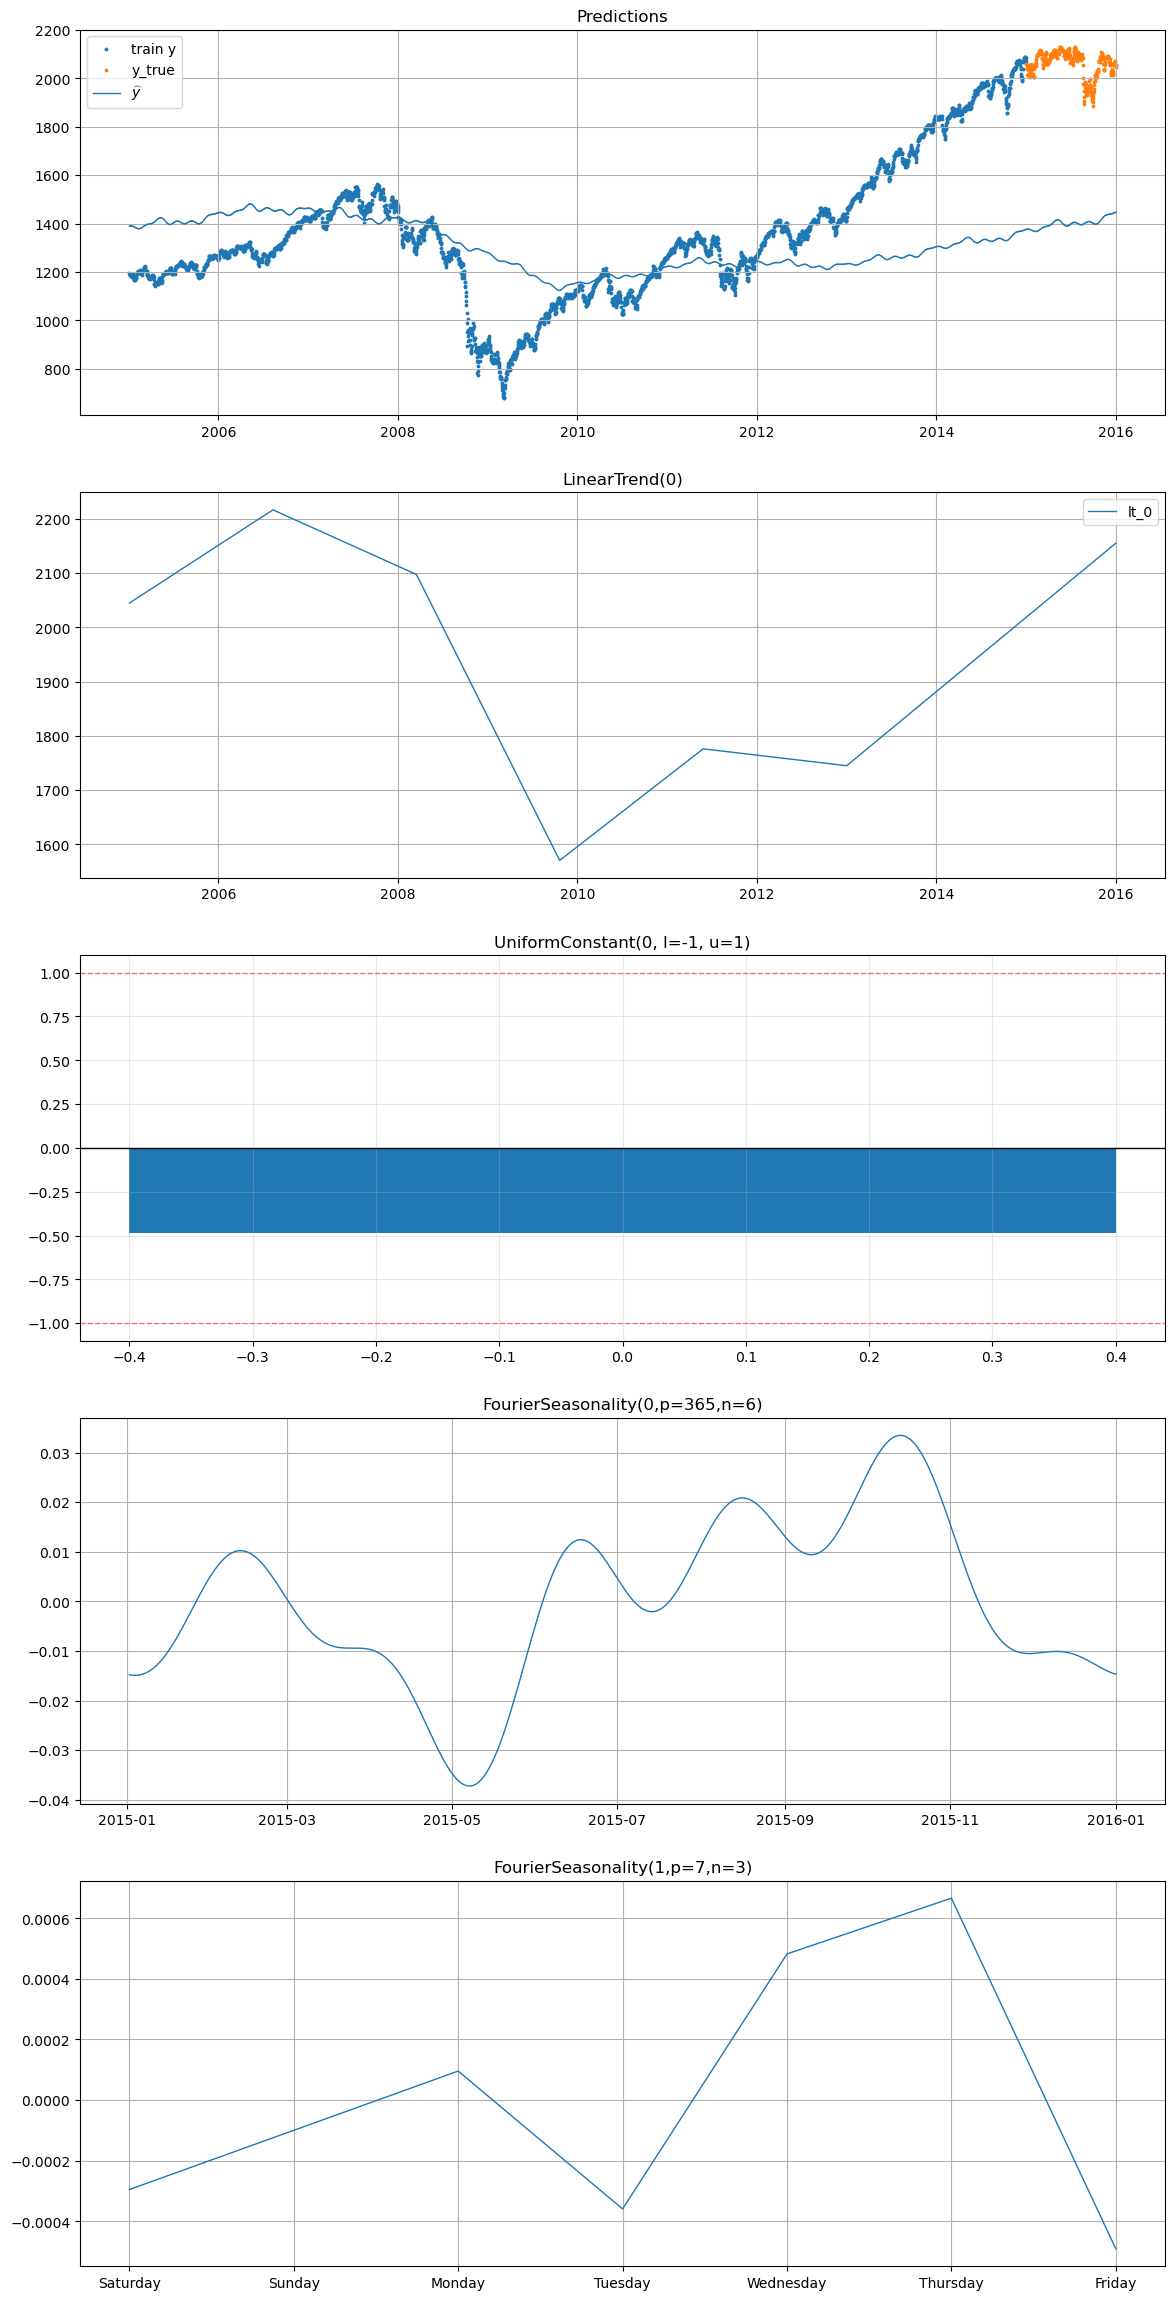

In [23]:
model.plot(yhat_tickers, series="^GSPC", y_true=all_dfs_test[all_dfs_test["series"] == "^GSPC"])

<Axes: title={'center': 'Prior Predictive Check'}, xlabel='Observation index', ylabel='y'>

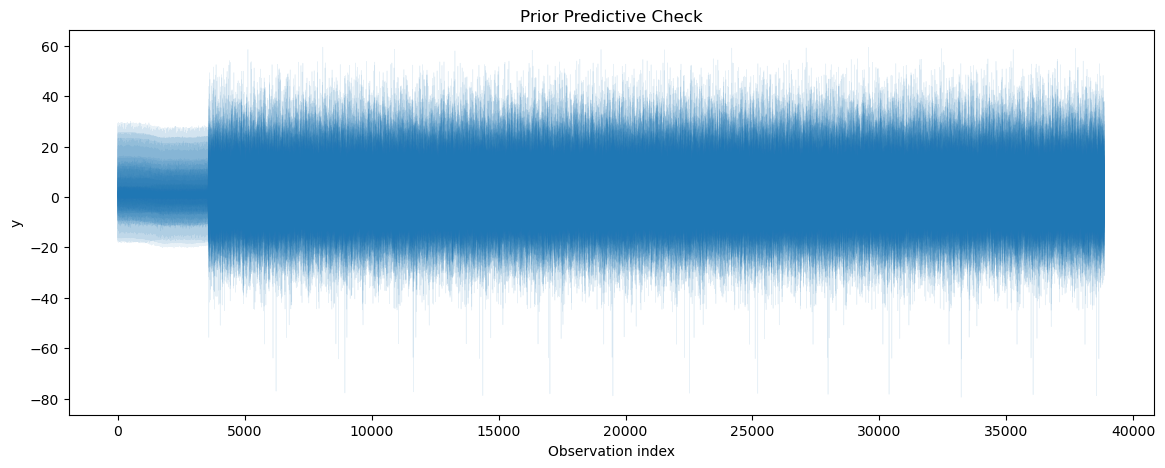

In [24]:
plot_prior_predictive(model_prior_predictive)